# **EDA_Optimising_NYC_Taxis_Khaleel_Husain**

# **New York City Yellow Taxi Data**

## Objective
In this case study you will be learning exploratory data analysis (EDA) with the help of a dataset on yellow taxi rides in New York City. This will enable you to understand why EDA is an important step in the process of data science and machine learning.

## **Problem Statement**
As an analyst at an upcoming taxi operation in NYC, you are tasked to use the 2023 taxi trip data to uncover insights that could help optimise taxi operations. The goal is to analyse patterns in the data that can inform strategic decisions to improve service efficiency, maximise revenue, and enhance passenger experience.

## Tasks
You need to perform the following steps for successfully completing this assignment:
1. Data Loading
2. Data Cleaning
3. Exploratory Analysis: Bivariate and Multivariate
4. Creating Visualisations to Support the Analysis
5. Deriving Insights and Stating Conclusions

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Understanding
The yellow taxi trip records include fields capturing pick-up and drop-off dates/times, pick-up and drop-off locations, trip distances, itemized fares, rate types, payment types, and driver-reported passenger counts.

The data is stored in Parquet format (*.parquet*). The dataset is from 2009 to 2024. However, for this assignment, we will only be using the data from 2023.

The data for each month is present in a different parquet file. You will get twelve files for each of the months in 2023.

The data was collected and provided to the NYC Taxi and Limousine Commission (TLC) by technology providers like vendors and taxi hailing apps. <br>

You can find the link to the TLC trip records page here: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

###  Data Description
You can find the data description here: [Data Dictionary](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf)

**Trip Records**



|Field Name       |description |
|:----------------|:-----------|
| VendorID | A code indicating the TPEP provider that provided the record. <br> 1= Creative Mobile Technologies, LLC; <br> 2= VeriFone Inc. |
| tpep_pickup_datetime | The date and time when the meter was engaged.  |
| tpep_dropoff_datetime | The date and time when the meter was disengaged.   |
| Passenger_count | The number of passengers in the vehicle. <br> This is a driver-entered value. |
| Trip_distance | The elapsed trip distance in miles reported by the taximeter. |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged |
|RateCodeID |The final rate code in effect at the end of the trip.<br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br>4 = Nassau or Westchester <br>5 = Negotiated fare <br>6 = Group ride |
|Store_and_fwd_flag |This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server.  <br>Y= store and forward trip <br>N= not a store and forward trip |
|Payment_type| A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br>2 = Cash <br>3 = No charge <br>4 = Dispute <br>5 = Unknown <br>6 = Voided trip |
|Fare_amount| The time-and-distance fare calculated by the meter. <br>Extra Miscellaneous extras and surcharges.  Currently, this only includes the 0.50 and 1 USD rush hour and overnight charges. |
|MTA_tax |0.50 USD MTA tax that is automatically triggered based on the metered rate in use. |
|Improvement_surcharge | 0.30 USD improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
|Tip_amount |Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| Tolls_amount | Total amount of all tolls paid in trip.  |
| total_amount | The total amount charged to passengers. Does not include cash tips. |
|Congestion_Surcharge |Total amount collected in trip for NYS congestion surcharge. |
| Airport_fee | 1.25 USD for pick up only at LaGuardia and John F. Kennedy Airports|

Although the amounts of extra charges and taxes applied are specified in the data dictionary, you will see that some cases have different values of these charges in the actual data.

**Taxi Zones**

Each of the trip records contains a field corresponding to the location of the pickup or drop-off of the trip, populated by numbers ranging from 1-263.

These numbers correspond to taxi zones, which may be downloaded as a table or map/shapefile and matched to the trip records using a join.

This is covered in more detail in later sections.

---

## **1** Data Preparation

<font color = red>[5 marks]</font> <br>

### Import Libraries

In [1]:
# Import warnings
import warnings


In [2]:
# Import the libraries you will be using for analysis

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Recommended versions
# numpy version: 1.26.4
# pandas version: 2.2.2
# matplotlib version: 3.10.0
# seaborn version: 0.13.2

# Check versions
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:", plt.matplotlib.__version__)
print("seaborn version:", sns.__version__)

numpy version: 2.1.3
pandas version: 2.2.3
matplotlib version: 3.10.0
seaborn version: 0.13.2


### **1.1** Load the dataset
<font color = red>[5 marks]</font> <br>

You will see twelve files, one for each month.

To read parquet files with Pandas, you have to follow a similar syntax as that for CSV files.

`df = pd.read_parquet('file.parquet')`

In [4]:
# Try loading one file
df = pd.read_parquet(r"D:\Upgrad Course\Module 4\APAGAI - Assignment - EDA\Starter_Notebook-EDA_NYC_Taxi\dataset\trip_records\2023-1.parquet")
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3041714 entries, 0 to 3066765
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee            floa

How many rows are there? Do you think handling such a large number of rows is computationally feasible when we have to combine the data for all twelve months into one?

To handle this, we need to sample a fraction of data from each of the files. How to go about that? Think of a way to select only some portion of the data from each month's file that accurately represents the trends.

#### Sampling the Data
> One way is to take a small percentage of entries for pickup in every hour of a date. So, for all the days in a month, we can iterate through the hours and select 5% values randomly from those. Use `tpep_pickup_datetime` for this. Separate date and hour from the datetime values and then for each date, select some fraction of trips for each of the 24 hours.

To sample data, you can use the `sample()` method. Follow this syntax:

```Python
# sampled_data is an empty DF to keep appending sampled data of each hour
# hour_data is the DF of entries for an hour 'X' on a date 'Y'

sample = hour_data.sample(frac = 0.05, random_state = 42)
# sample 0.05 of the hour_data
# random_state is just a seed for sampling, you can define it yourself

sampled_data = pd.concat([sampled_data, sample]) # adding data for this hour to the DF
```

This *sampled_data* will contain 5% values selected at random from each hour.

Note that the code given above is only the part that will be used for sampling and not the complete code required for sampling and combining the data files.

Keep in mind that you sample by date AND hour, not just hour. (Why?)

---

**1.1.1** <font color = red>[5 marks]</font> <br>
Figure out how to sample and combine the files.

**Note:** It is not mandatory to use the method specified above. While sampling, you only need to make sure that your sampled data represents the overall data of all the months accurately.

In [5]:
# Sample the data
# It is recommmended to not load all the files at once to avoid memory overload

In [6]:
# from google.colab import drive
# drive.mount('/content/drive')

In [7]:
# Take a small percentage of entries from each hour of every date.
# Iterating through the monthly data:
#   read a month file -> day -> hour: append sampled data -> move to next hour -> move to next day after 24 hours -> move to next month file
# Create a single dataframe for the year combining all the monthly data

# Select the folder having data files
import os

# initialise an empty dataframe
df = pd.DataFrame()

# Initialise an empty list to store sampled dataframes
sampled_list = []

# Update this path to your local directory
data_path = r"D:\Upgrad Course\Module 4\APAGAI - Assignment - EDA\Starter_Notebook-EDA_NYC_Taxi\dataset\trip_records"
os.chdir(data_path)

file_list = [f for f in os.listdir() if f.endswith('.parquet')]

for file_name in file_list:
    try:
        print(f"Processing {file_name}...")
        # FIXED: Read the current file_name from the loop
        month_df = pd.read_parquet(file_name)
        
        # Ensure pickup datetime is in datetime format
        month_df['tpep_pickup_datetime'] = pd.to_datetime(month_df['tpep_pickup_datetime'])
        
        # Create temporary columns for grouping
        month_df['temp_date'] = month_df['tpep_pickup_datetime'].dt.date
        month_df['temp_hour'] = month_df['tpep_pickup_datetime'].dt.hour
        
        # Group by Date and Hour, then sample 2% (as per your snippet)
        sample = month_df.groupby(['temp_date', 'temp_hour'], group_keys=False).apply(
            lambda x: x.sample(frac=0.02, random_state=42) if len(x) > 0 else x
        ).reset_index(drop=True)
        
        # Drop temporary columns
        sample = sample.drop(columns=['temp_date', 'temp_hour'])
        
        sampled_list.append(sample)
        
        # Memory cleanup
        del month_df
        
    except Exception as e:
        print(f"Error reading file {file_name}: {e}")

# Combine all months
df = pd.concat(sampled_list, ignore_index=True)

print(f"Total sampled rows: {len(df)}")

Processing 2023-1.parquet...


C:\Users\khale\AppData\Local\Temp\ipykernel_1336\2106533324.py:35: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample = month_df.groupby(['temp_date', 'temp_hour'], group_keys=False).apply(


Processing 2023-10.parquet...


C:\Users\khale\AppData\Local\Temp\ipykernel_1336\2106533324.py:35: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample = month_df.groupby(['temp_date', 'temp_hour'], group_keys=False).apply(


Processing 2023-11.parquet...


...

C:\Users\khale\AppData\Local\Temp\ipykernel_1336\2106533324.py:35: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample = month_df.groupby(['temp_date', 'temp_hour'], group_keys=False).apply(


Processing 2023-9.parquet...


C:\Users\khale\AppData\Local\Temp\ipykernel_1336\2106533324.py:35: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample = month_df.groupby(['temp_date', 'temp_hour'], group_keys=False).apply(


Processing 2023-taxi-sampled.parquet...
Total sampled rows: 773672


C:\Users\khale\AppData\Local\Temp\ipykernel_1336\2106533324.py:35: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample = month_df.groupby(['temp_date', 'temp_hour'], group_keys=False).apply(


After combining the data files into one DataFrame, convert the new DataFrame to a CSV or parquet file and store it to use directly.

Ideally, you can try keeping the total entries to around 250,000 to 300,000.

In [8]:
# Store the df in csv/parquet
df.to_parquet(r"D:\Upgrad Course\Module 4\APAGAI - Assignment - EDA\Starter_Notebook-EDA_NYC_Taxi\dataset\trip_records\2023-taxi-sampled.parquet")

## **2** Data Cleaning
<font color = red>[30 marks]</font> <br>

Now we can load the new data directly.

In [9]:
# Load the new data file
df = pd.read_parquet(r"D:\Upgrad Course\Module 4\APAGAI - Assignment - EDA\Starter_Notebook-EDA_NYC_Taxi\dataset\trip_records\2023-taxi-sampled.parquet")


In [10]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,Airport_fee
0,2,2023-01-01 00:07:18,2023-01-01 00:23:15,1.0,7.74,1.0,N,138,256,2,32.40,6.0,0.5,0.00,0.0,1.0,41.15,0.0,1.25,NaN
1,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2.0,1.24,1.0,N,161,237,1,7.90,1.0,0.5,2.58,0.0,1.0,15.48,2.5,0.00,NaN
2,2,2023-01-01 00:14:03,2023-01-01 00:24:36,3.0,1.44,1.0,N,237,141,2,11.40,1.0,0.5,0.00,0.0,1.0,16.40,2.5,0.00,NaN
3,2,2023-01-01 00:24:30,2023-01-01 00:29:55,1.0,0.54,1.0,N,143,142,2,6.50,1.0,0.5,0.00,0.0,1.0,11.50,2.5,0.00,NaN
4,2,2023-01-01 00:43:00,2023-01-01 01:01:00,NaN,19.24,NaN,None,66,107,0,25.64,0.0,0.5,5.93,0.0,1.0,35.57,NaN,NaN,NaN


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 773672 entries, 0 to 773671
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               773672 non-null  int64         
 1   tpep_pickup_datetime   773672 non-null  datetime64[us]
 2   tpep_dropoff_datetime  773672 non-null  datetime64[us]
 3   passenger_count        747540 non-null  float64       
 4   trip_distance          773672 non-null  float64       
 5   RatecodeID             747540 non-null  float64       
 6   store_and_fwd_flag     747540 non-null  object        
 7   PULocationID           773672 non-null  int64         
 8   DOLocationID           773672 non-null  int64         
 9   payment_type           773672 non-null  int64         
 10  fare_amount            773672 non-null  float64       
 11  extra                  773672 non-null  float64       
 12  mta_tax                773672 non-null  floa

#### **2.1** Fixing Columns
<font color = red>[10 marks]</font> <br>

Fix/drop any columns as you seem necessary in the below sections

**2.1.1** <font color = red>[2 marks]</font> <br>

Fix the index and drop unnecessary columns

In [12]:
# Fix the index and drop any columns that are not needed

# 2. Reset the index so it is continuous (0, 1, 2...)
df.reset_index(drop=True, inplace=True)

# 3. Drop columns that are not necessary for the analysis
# 'store_and_fwd_flag' is usually a technical flag with little analytical value
cols_to_drop = ['store_and_fwd_flag']
df.drop(columns=[col for col in cols_to_drop if col in df.columns], inplace=True)

print("Index fixed and unnecessary columns dropped.")
df.head()


Index fixed and unnecessary columns dropped.


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,Airport_fee
0,2,2023-01-01 00:07:18,2023-01-01 00:23:15,1.0,7.74,1.0,138,256,2,32.40,6.0,0.5,0.00,0.0,1.0,41.15,0.0,1.25,NaN
1,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2.0,1.24,1.0,161,237,1,7.90,1.0,0.5,2.58,0.0,1.0,15.48,2.5,0.00,NaN
2,2,2023-01-01 00:14:03,2023-01-01 00:24:36,3.0,1.44,1.0,237,141,2,11.40,1.0,0.5,0.00,0.0,1.0,16.40,2.5,0.00,NaN
3,2,2023-01-01 00:24:30,2023-01-01 00:29:55,1.0,0.54,1.0,143,142,2,6.50,1.0,0.5,0.00,0.0,1.0,11.50,2.5,0.00,NaN
4,2,2023-01-01 00:43:00,2023-01-01 01:01:00,NaN,19.24,NaN,66,107,0,25.64,0.0,0.5,5.93,0.0,1.0,35.57,NaN,NaN,NaN


**2.1.2** <font color = red>[3 marks]</font> <br>
There are two airport fee columns. This is possibly an error in naming columns. Let's see whether these can be combined into a single column.

In [13]:
# Combine the two airport fee columns
df['airport_fee'] = df['airport_fee'].fillna(df['Airport_fee'])
  
# Drop the redundant uppercase column
df.drop(columns=['Airport_fee'], inplace=True)
print("Successfully combined 'Airport_fee' and 'airport_fee'.")

Successfully combined 'Airport_fee' and 'airport_fee'.


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 773672 entries, 0 to 773671
Data columns (total 18 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               773672 non-null  int64         
 1   tpep_pickup_datetime   773672 non-null  datetime64[us]
 2   tpep_dropoff_datetime  773672 non-null  datetime64[us]
 3   passenger_count        747540 non-null  float64       
 4   trip_distance          773672 non-null  float64       
 5   RatecodeID             747540 non-null  float64       
 6   PULocationID           773672 non-null  int64         
 7   DOLocationID           773672 non-null  int64         
 8   payment_type           773672 non-null  int64         
 9   fare_amount            773672 non-null  float64       
 10  extra                  773672 non-null  float64       
 11  mta_tax                773672 non-null  float64       
 12  tip_amount             773672 non-null  floa

**2.1.3** <font color = red>[5 marks]</font> <br>
Fix columns with negative (monetary) values

In [15]:
# check where values of fare amount are negative
neg_counts = (df['fare_amount'] < 0).sum()
print("Negative values found in fare amount before fix:\n", neg_counts[neg_counts > 0])

Negative values found in fare amount before fix:
 []


Did you notice something different in the `RatecodeID` column for above records?

In [16]:
# Analyse RatecodeID for the negative fare amounts
df[df['fare_amount'] < 0]['RatecodeID'].unique()


array([], dtype=float64)

In [17]:
# Find which columns have negative values

# List of columns that represent money
monetary_cols = [
    'fare_amount', 'extra', 'mta_tax', 'tip_amount', 
    'tolls_amount', 'improvement_surcharge', 
    'total_amount', 'congestion_surcharge', 'airport_fee']

neg_counts = (df[monetary_cols] < 0).sum()
print("Negative values found in all monetary columns before fix:\n", neg_counts[neg_counts > 0])

Negative values found in all monetary columns before fix:
 extra                     2
mta_tax                  37
improvement_surcharge    39
total_amount             39
congestion_surcharge     30
airport_fee               7
dtype: int64


In [18]:
# fix these negative values

# Fix: Convert negative values to positive (absolute value)
for col in monetary_cols:
    if col in df.columns:
        df[col] = df[col].abs()

# Verification check
print("\nNegative values after fix:", (df[monetary_cols] < 0).sum())



Negative values after fix: fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
congestion_surcharge     0
airport_fee              0
dtype: int64


### **2.2** Handling Missing Values
<font color = red>[10 marks]</font> <br>

**2.2.1**  <font color = red>[2 marks]</font> <br>
Find the proportion of missing values in each column




In [19]:
# Find the proportion of missing values in each column
missing_props = (df.isnull().sum() / len(df)) * 100

# Filter to show only columns that actually have missing values
print("Proportion of missing values (%):")
print(missing_props[missing_props > 0].sort_values(ascending=False))

Proportion of missing values (%):
passenger_count         3.377659
RatecodeID              3.377659
congestion_surcharge    3.377659
airport_fee             3.377659
dtype: float64


**2.2.2**  <font color = red>[3 marks]</font> <br>
Handling missing values in `passenger_count`

In [20]:
# Display the rows with null values
null_passengers = df[df['passenger_count'].isnull()]
null_passengers.head()

# Impute NaN values in 'passenger_count': Fill NaN values with the mode (most frequent value)
mode_passenger = df['passenger_count'].mode()[0]
df['passenger_count'] = df['passenger_count'].fillna(mode_passenger)

#Handle 0 values (a trip must have at least one passenger or it's likely an error)
# Replace 0s with the mode as well
df['passenger_count'] = df['passenger_count'].replace(0, mode_passenger)


Did you find zeroes in passenger_count? Handle these.

**2.2.3**  <font color = red>[2 marks]</font> <br>
Handle missing values in `RatecodeID`

In [21]:
# Fix missing values in 'RatecodeID': Fill NaN values with 1 (Standard Rate)
df['RatecodeID'] = df['RatecodeID'].fillna(1.0)

print("Imputed missing RatecodeID with 1.0 (Standard Rate).")

Imputed missing RatecodeID with 1.0 (Standard Rate).


**2.2.4**  <font color = red>[3 marks]</font> <br>
Impute NaN in `congestion_surcharge`

In [22]:
# handle null values in congestion_surcharge : The congestion surcharge is typically $2.50 for Yellow Taxis.
most_freq_surcharge = df['congestion_surcharge'].mode()[0]

# Fill missing values
df['congestion_surcharge'] = df['congestion_surcharge'].fillna(most_freq_surcharge)

print(f"Imputed missing congestion_surcharge with mode: {most_freq_surcharge}")

Imputed missing congestion_surcharge with mode: 2.5


Are there missing values in other columns? Did you find NaN values in some other set of columns? Handle those missing values below.

In [23]:
# Handle any remaining missing values

remaining_nulls = df.isnull().sum()
print("Remaining nulls per column:\n", remaining_nulls[remaining_nulls > 0])

# Fill remaining numerical columns with 0
df = df.fillna(0)

print("\nFinal missing value check:", df.isnull().sum().sum())

Remaining nulls per column:
 airport_fee    26132
dtype: int64

Final missing value check: 0


### **2.3** Handling Outliers
<font color = red>[10 marks]</font> <br>

Before we start fixing outliers, let's perform outlier analysis.

In [24]:
# Describe the data and check if there are any potential outliers present
df.describe()
# Check for potential out of place values in various columns



,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
count,773672.000000,773672,773672,773672.000000,773672.000000,773672.000000,773672.000000,773672.000000,773672.000000,773672.000000,773672.000000,773672.000000,773672.000000,773672.000000,773672.000000,773672.000000,773672.000000,773672.000000
mean,1.733621,2023-07-02 20:07:22.423145,2023-07-02 20:24:45.515370,1.371558,3.699387,1.622102,165.289607,164.009490,1.164315,20.009229,1.585240,0.495316,3.540496,0.593018,0.999045,29.059480,2.313869,0.137815
min,1.000000,2023-01-01 00:02:19,2023-01-01 00:09:40,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,2023-04-02 16:10:25.750000,2023-04-02 16:31:09.750000,1.000000,1.050000,1.000000,132.000000,113.000000,1.000000,9.300000,0.000000,0.500000,1.000000,0.000000,1.000000,15.960000,2.500000,0.000000
50%,2.000000,2023-06-27 15:48:15,2023-06-27 16:06:42,1.000000,1.790000,1.000000,162.000000,162.000000,1.000000,13.500000,1.000000,0.500000,2.850000,0.000000,1.000000,21.000000,2.500000,0.000000
75%,2.000000,2023-10-06 19:52:43.250000,2023-10-06 20:08:59,1.000000,3.400000,1.000000,234.000000,234.000000,1.000000,21.900000,2.500000,0.500000,4.420000,0.000000,1.000000,30.800000,2.500000,0.000000
max,6.000000,2023-12-31 23:57:51,2024-01-01 20:14:57,9.000000,34804.510000,99.000000,265.000000,265.000000,4.000000,143163.450000,14.250000,4.000000,180.000000,143.000000,1.000000,143167.450000,2.500000,1.750000
std,0.447499,NaN,NaN,0.864130,72.197425,7.326717,63.975733,69.818157,0.507334,163.748477,1.826086,0.048611,4.020218,2.181822,0.028539,164.308863,0.656264,0.457189


**2.3.1**  <font color = red>[10 marks]</font> <br>
Based on the above analysis, it seems that some of the outliers are present due to errors in registering the trips. Fix the outliers.

Some points you can look for:
- Entries where `trip_distance` is nearly 0 and `fare_amount` is more than 300
- Entries where `trip_distance` and `fare_amount` are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
- Entries where `trip_distance` is more than 250  miles.
- Entries where `payment_type` is 0 (there is no payment_type 0 defined in the data dictionary)

These are just some suggestions. You can handle outliers in any way you wish, using the insights from above outlier analysis.

How will you fix each of these values? Which ones will you drop and which ones will you replace?

First, let us remove 7+ passenger counts as there are very less instances.

In [25]:
# remove passenger_count > 6
# Identify and remove rows where passenger_count is greater than 6
print(f"Rows before passenger filter: {len(df)}")
df = df[df['passenger_count'] <= 6]
print(f"Rows after passenger filter: {len(df)}")

Rows before passenger filter: 773672
Rows after passenger filter: 773663


In [26]:
# Continue with outlier handling
# 1. Drop: trip_distance is nearly 0 but fare_amount > 300 (likely GPS error/manual overcharge)
df = df[~((df['trip_distance'] <= 0.1) & (df['fare_amount'] > 300))]

# 2. Drop: distance AND fare are 0 but pickup/dropoff zones are DIFFERENT
# (If zones are different, the car had to move, so distance/fare cannot be 0)
df = df[~((df['trip_distance'] == 0) & (df['fare_amount'] == 0) & (df['PULocationID'] != df['DOLocationID']))]

# 3. Drop: trip_distance is more than 250 miles 
# (NYC taxis rarely leave the tri-state area; 250+ miles is usually a sensor error)
df = df[df['trip_distance'] <= 250]

# 4. Drop: payment_type is 0 (Undefined in the data dictionary)
df = df[df['payment_type'] != 0]

print(f"Final row count after outlier handling: {len(df)}")


Final row count after outlier handling: 747483


In [27]:
# Do any columns need standardising?

# Ensure datetime columns are correctly typed
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

# Optional: Create a 'trip_duration' column (in minutes) as it's useful for Section 3
df['trip_duration'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60

# Filter out negative or zero durations (trips that end before they start)
df = df[df['trip_duration'] > 0]


## **3** Exploratory Data Analysis
<font color = red>[90 marks]</font> <br>

In [28]:
df.columns.tolist()

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'airport_fee',
 'trip_duration']

#### **3.1** General EDA: Finding Patterns and Trends
<font color = red>[40 marks]</font> <br>

**3.1.1** <font color = red>[3 marks]</font> <br>
Categorise the varaibles into Numerical or Categorical.
* `VendorID`:
* `tpep_pickup_datetime`:
* `tpep_dropoff_datetime`:
* `passenger_count`:
* `trip_distance`:
* `RatecodeID`:
* `PULocationID`:
* `DOLocationID`:
* `payment_type`:
* `pickup_hour`:
* `trip_duration`:


The following monetary parameters belong in the same category, is it categorical or numerical?


* `fare_amount`
* `extra`
* `mta_tax`
* `tip_amount`
* `tolls_amount`
* `improvement_surcharge`
* `total_amount`
* `congestion_surcharge`
* `airport_fee`

##### Temporal Analysis

**3.1.2** <font color = red>[5 marks]</font> <br>
Analyse the distribution of taxi pickups by hours, days of the week, and months.

In [29]:
# 1. Feature Extraction
# Extract Hour, Day of Week, and Month from the pickup datetime
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['day_of_week'] = df['tpep_pickup_datetime'].dt.day_name()
df['month'] = df['tpep_pickup_datetime'].dt.month_name()

# Define categorical order for days and months to ensure plots are chronological
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

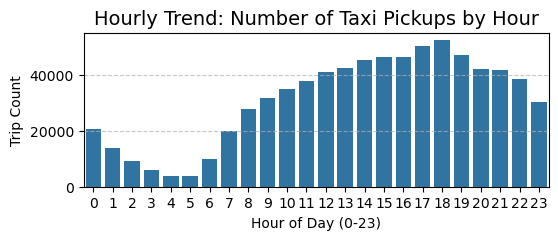

In [30]:
# Find and show the hourly trends in taxi pickups
plt.figure(figsize=(6, 2))
sns.countplot(data=df, x='pickup_hour')
plt.title('Hourly Trend: Number of Taxi Pickups by Hour', fontsize=14)
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Trip Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

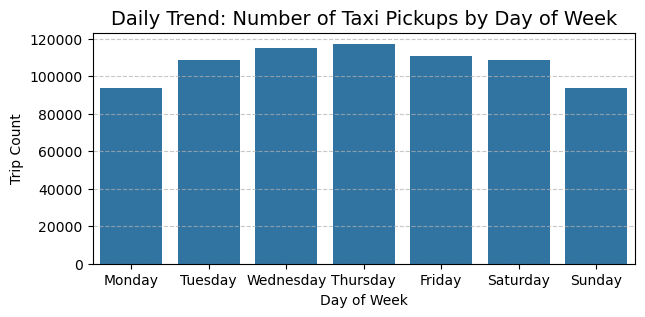

In [31]:
# Find and show the daily trends in taxi pickups (days of the week)
plt.figure(figsize=(7, 3))
sns.countplot(data=df, x='day_of_week', order=day_order)
plt.title('Daily Trend: Number of Taxi Pickups by Day of Week', fontsize=14)
plt.xlabel('Day of Week')
plt.ylabel('Trip Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

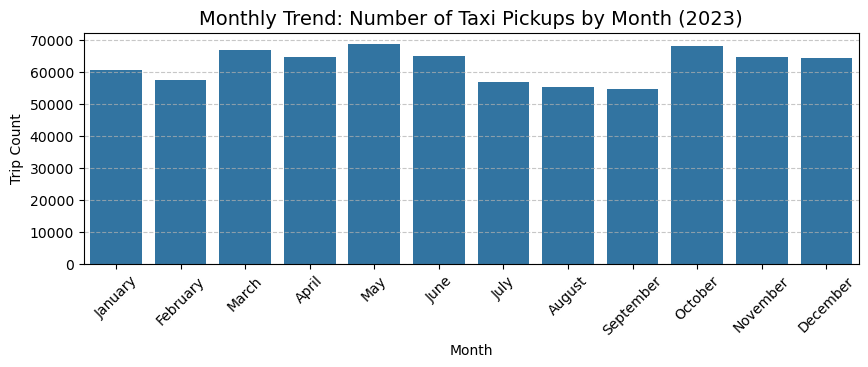

In [32]:
# Show the monthly trends in pickups
plt.figure(figsize=(10, 3))
sns.countplot(data=df, x='month', order=month_order)
plt.title('Monthly Trend: Number of Taxi Pickups by Month (2023)', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Trip Count')
plt.xticks(rotation=45) # Rotate month names for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

##### Financial Analysis

Take a look at the financial parameters like `fare_amount`, `tip_amount`, `total_amount`, and also `trip_distance`. Do these contain zero/negative values?

In [33]:
# Analyse the above parameters
# List of specific columns to check
check_cols = ['fare_amount', 'tip_amount', 'total_amount', 'trip_distance']

# Create a summary table for Zero and Negative values
check_summary = pd.DataFrame({
    'Negative Values': (df[check_cols] < 0).sum(),
    'Zero Values': (df[check_cols] == 0).sum()
})

print("Sanity Check for Financial & Distance Parameters:")
print(check_summary)

Sanity Check for Financial & Distance Parameters:
               Negative Values  Zero Values
fare_amount                  0          256
tip_amount                   0       167075
total_amount                 0          104
trip_distance                0         9188


Do you think it is beneficial to create a copy DataFrame leaving out the zero values from these?

**3.1.3** <font color = red>[2 marks]</font> <br>
Filter out the zero values from the above columns.

**Note:** The distance might be 0 in cases where pickup and drop is in the same zone. Do you think it is suitable to drop such cases of zero distance?

In [34]:
# Create a df with non zero entries for the selected parameters.
# we create a filtered copy for financial distribution analysis
# We filter for trips where these core metrics are greater than zero
print(f"Original rows: {len(df)}")
df_original = df.copy()
df = df[(df['fare_amount'] > 0) & 
                (df['total_amount'] > 0) & 
                (df['trip_distance'] > 0)].copy()

# Note: We don't necessarily filter tip_amount > 0 here 
# because many valid trips have $0 tips. 
# We usually filter tip_amount only when plotting the tip distribution.

print(f"Rows after filtering zeros in distance/fare: {len(df)}")

Original rows: 747205
Rows after filtering zeros in distance/fare: 737872


**3.1.4** <font color = red>[3 marks]</font> <br>
Analyse the monthly revenue (`total_amount`) trend

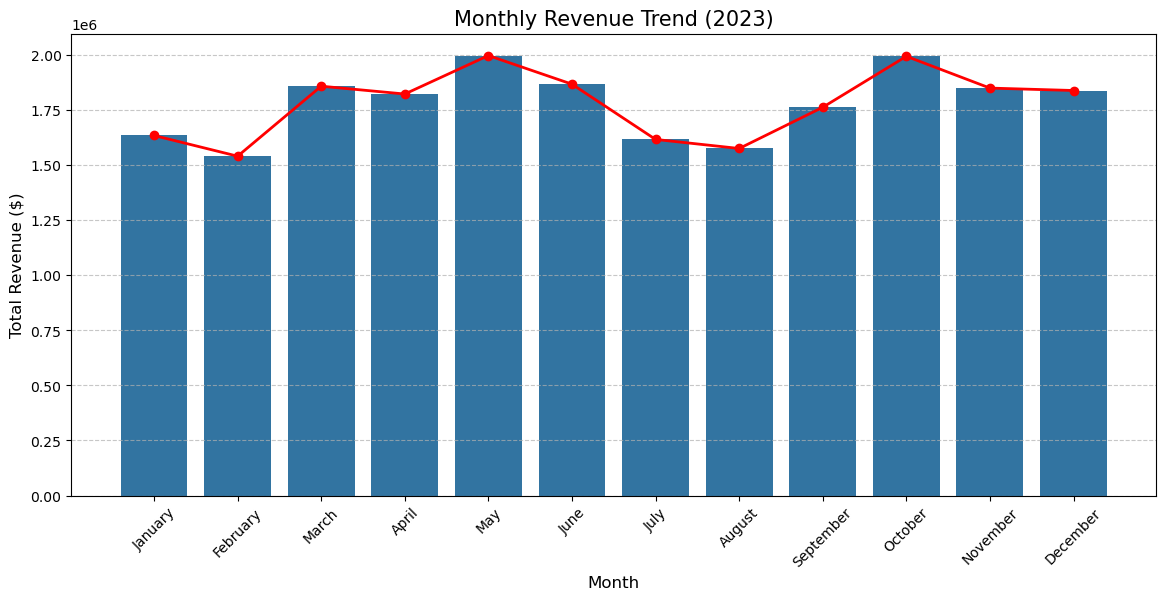

Monthly Revenue Summary:
        month  total_amount
0     January    1634111.72
1    February    1540182.50
2       March    1857883.81
3       April    1822360.66
4         May    1996948.24
5        June    1867012.40
6        July    1616309.52
7      August    1575167.26
8   September    1762168.45
9     October    1993514.25
10   November    1849282.38
11   December    1838326.80


In [35]:
# Group data by month and analyse monthly revenue
#  Group by month and sum the total_amount
monthly_revenue = df.groupby('month')['total_amount'].sum().reindex(month_order).reset_index()

# 3. Visualization
plt.figure(figsize=(14, 6))
sns.barplot(data=monthly_revenue, x='month', y='total_amount')

# Adding a line plot on top to highlight the trend
plt.plot(monthly_revenue['month'], monthly_revenue['total_amount'], marker='o', color='red', linewidth=2)

plt.title('Monthly Revenue Trend (2023)', fontsize=15)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# Print the numeric values for the report
print("Monthly Revenue Summary:")
print(monthly_revenue)


**3.1.5** <font color = red>[3 marks]</font> <br>
Show the proportion of each quarter of the year in the revenue

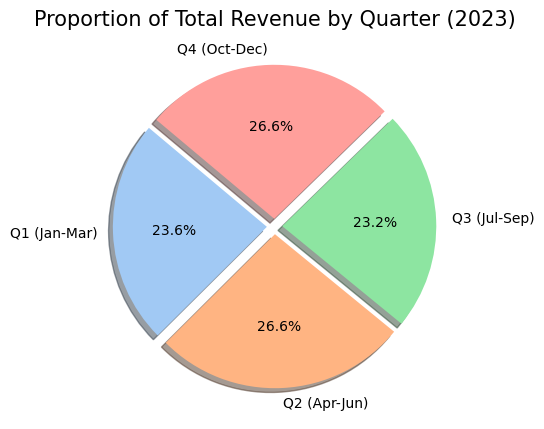

Quarterly Revenue Distribution:
quarter
Q1 (Jan-Mar)    5032178.03
Q2 (Apr-Jun)    5686321.30
Q3 (Jul-Sep)    4953645.23
Q4 (Oct-Dec)    5681123.43
Name: total_amount, dtype: float64


In [36]:
# Calculate proportion of each quarter
# 1. Extract the quarter from the pickup datetime
# .dt.quarter returns 1, 2, 3, or 4
df['quarter'] = df['tpep_pickup_datetime'].dt.quarter

# 2. Group by quarter and calculate the sum of total_amount
quarterly_revenue = df.groupby('quarter')['total_amount'].sum()

# 3. Map numeric quarters to descriptive labels for the plot
quarter_labels = {
    1: 'Q1 (Jan-Mar)', 
    2: 'Q2 (Apr-Jun)', 
    3: 'Q3 (Jul-Sep)', 
    4: 'Q4 (Oct-Dec)'
}
quarterly_revenue.index = quarterly_revenue.index.map(quarter_labels)

# 4. Visualization: Pie Chart
plt.figure(figsize=(5, 5))
colors = sns.color_palette('pastel')[0:4]

plt.pie(quarterly_revenue, 
        labels=quarterly_revenue.index, 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=colors,
        explode=(0.05, 0.05, 0.05, 0.05), # Slightly separate the slices
        shadow=True)

plt.title('Proportion of Total Revenue by Quarter (2023)', fontsize=15)
plt.show()

# Print the table for your report
print("Quarterly Revenue Distribution:")
print(quarterly_revenue)


**3.1.6** <font color = red>[3 marks]</font> <br>
Visualise the relationship between `trip_distance` and `fare_amount`. Also find the correlation value for these two.

**Hint:** You can leave out the trips with trip_distance = 0

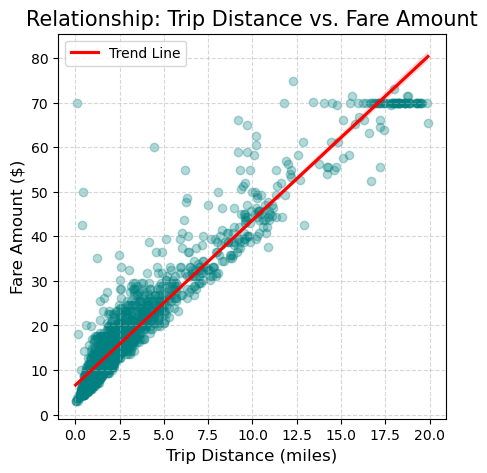

Correlation Coefficient:                trip_distance  fare_amount
trip_distance       1.000000     0.099479
fare_amount         0.099479     1.000000


In [37]:
# Show how trip fare is affected by distance
# 1. Filter for valid trips (Distance and Fare > 0)
# We also limit the plot to the 99th percentile to remove extreme outliers for better visibility
plot_data = df[(df['trip_distance'] > 0) & (df['trip_distance'] < df['trip_distance'].quantile(0.99)) & 
               (df['fare_amount'] > 0) & (df['fare_amount'] < df['fare_amount'].quantile(0.99))]

# 2. Create the Regression Plot
plt.figure(figsize=(5, 5))
sns.regplot(data=plot_data.sample(2000), x='trip_distance', y='fare_amount', 
            scatter_kws={'alpha':0.3, 'color':'teal'}, 
            line_kws={'color':'red', 'label':'Trend Line'})

plt.title('Relationship: Trip Distance vs. Fare Amount', fontsize=15)
plt.xlabel('Trip Distance (miles)', fontsize=12)
plt.ylabel('Fare Amount ($)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 3. Calculate the Correlation Coefficient
correlation = df[['trip_distance', 'fare_amount']].corr()
print(f"Correlation Coefficient: {correlation}")


**3.1.7** <font color = red>[5 marks]</font> <br>
Find and visualise the correlation between:
1. `fare_amount` and trip duration (pickup time to dropoff time)
2. `fare_amount` and `passenger_count`
3. `tip_amount` and `trip_distance`

Text(0, 0.5, 'Fare ($)')

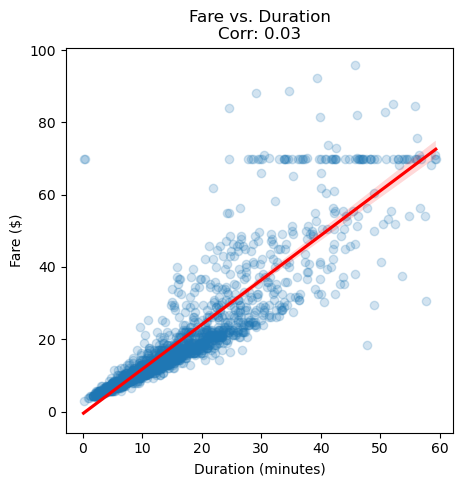

In [38]:
# Show relationship between fare and trip duration
# 1. Fare Amount vs. Trip Duration
# Filter out logical outliers for cleaner visualization (99th percentile)
filtered_df = df[(df['trip_duration'] > 0) & (df['trip_duration'] < 60) & 
                 (df['fare_amount'] > 0) & (df['fare_amount'] < 100) &
                 (df['trip_distance'] > 0) & (df['trip_distance'] < 50)].copy()

plt.figure(figsize=(5, 5))
sns.regplot(data=filtered_df.sample(2000), x='trip_duration', y='fare_amount', scatter_kws={'alpha':0.2}, line_kws={'color':'red'})
plt.title(f"Fare vs. Duration\nCorr: {df['fare_amount'].corr(df['trip_duration']):.2f}")
plt.xlabel("Duration (minutes)")
plt.ylabel("Fare ($)")


Text(0, 0.5, 'Fare ($)')

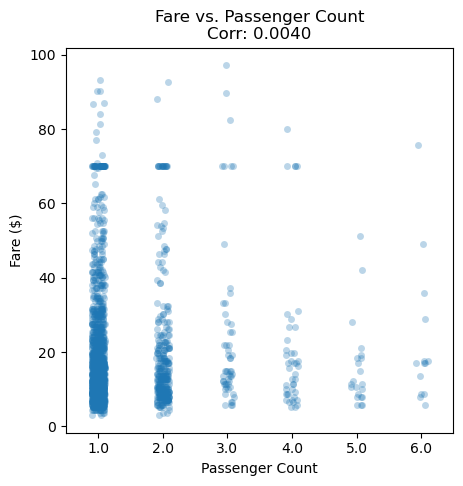

In [39]:
# Show relationship between fare and number of passengers

plt.figure(figsize=(5, 5))
sns.stripplot(data=filtered_df.sample(2000), x='passenger_count', y='fare_amount', alpha=0.3, jitter=True)
plt.title(f"Fare vs. Passenger Count\nCorr: {df['fare_amount'].corr(df['passenger_count']):.4f}")
plt.xlabel("Passenger Count")
plt.ylabel("Fare ($)")


Text(0, 0.5, 'Tip ($)')

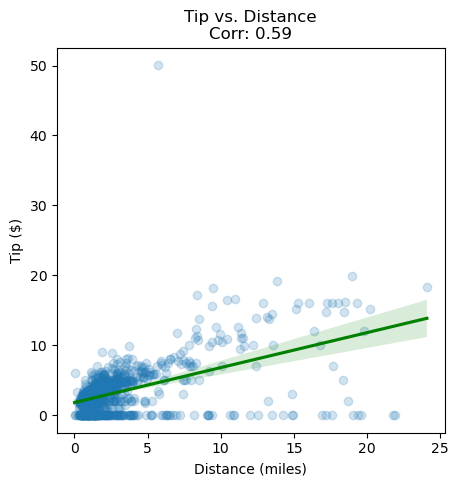

In [40]:
# Show relationship between tip and trip distance

plt.figure(figsize=(5, 5))
sns.regplot(data=filtered_df.sample(1000), x='trip_distance', y='tip_amount', scatter_kws={'alpha':0.2}, line_kws={'color':'green'})
plt.title(f"Tip vs. Distance\nCorr: {df['tip_amount'].corr(df['trip_distance']):.2f}")
plt.xlabel("Distance (miles)")
plt.ylabel("Tip ($)")

**3.1.8** <font color = red>[3 marks]</font> <br>
Analyse the distribution of different payment types (`payment_type`)

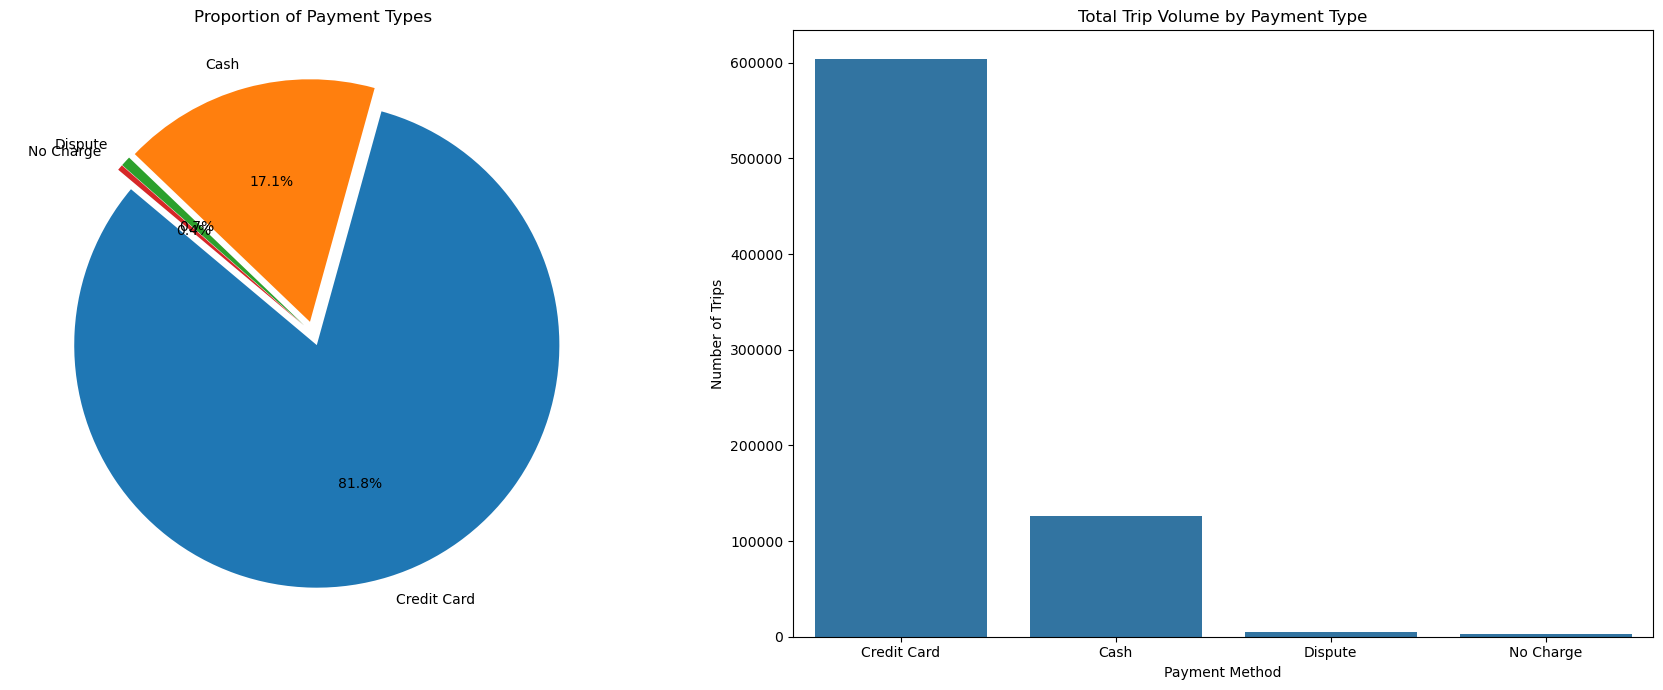

Payment Type Counts:
payment_label
Credit Card    603686
Cash           126490
Dispute          4938
No Charge        2758
Name: count, dtype: int64


In [41]:
# Analyse the distribution of different payment types (payment_type).
# 1. Map the numeric codes to their actual names
payment_map = {
    1: 'Credit Card',
    2: 'Cash',
    3: 'No Charge',
    4: 'Dispute'
}
df['payment_label'] = df['payment_type'].map(payment_map)

# 2. Set up the visualization (Pie Chart and Count Plot)
fig, ax = plt.subplots(1, 2, figsize=(18, 7))

# Pie Chart for Proportion
payment_counts = df['payment_label'].value_counts()
ax[0].pie(payment_counts, labels=payment_counts.index, autopct='%1.1f%%', 
          startangle=140, explode=[0.05]*len(payment_counts))
ax[0].set_title('Proportion of Payment Types')

# Count Plot for Absolute Volume
sns.countplot(data=df, x='payment_label', ax=ax[1], order=payment_counts.index)
ax[1].set_title('Total Trip Volume by Payment Type')
ax[1].set_ylabel('Number of Trips')
ax[1].set_xlabel('Payment Method')

plt.tight_layout()
plt.show()

# 3. Print the value counts for precise reporting
print("Payment Type Counts:")
print(payment_counts)



- 1= Credit card
- 2= Cash
- 3= No charge
- 4= Dispute



##### Geographical Analysis

For this, you have to use the *taxi_zones.shp* file from the *taxi_zones* folder.

There would be multiple files inside the folder (such as *.shx, .sbx, .sbn* etc). You do not need to import/read any of the files other than the shapefile, *taxi_zones.shp*.

Do not change any folder structure - all the files need to be present inside the folder for it to work.

The folder structure should look like this:
```
Taxi Zones
|- taxi_zones.shp.xml
|- taxi_zones.prj
|- taxi_zones.sbn
|- taxi_zones.shp
|- taxi_zones.dbf
|- taxi_zones.shx
|- taxi_zones.sbx

 ```

 You only need to read the `taxi_zones.shp` file. The *shp* file will utilise the other files by itself.

We will use the *GeoPandas* library for geopgraphical analysis
```
import geopandas as gpd
```

More about geopandas and shapefiles: [About](https://geopandas.org/en/stable/about.html)


Reading the shapefile is very similar to *Pandas*. Use `gpd.read_file()` function to load the data (*taxi_zones.shp*) as a GeoDataFrame. Documentation: [Reading and Writing Files](https://geopandas.org/en/stable/docs/user_guide/io.html)

In [42]:
!pip install geopandas

**3.1.9** <font color = red>[2 marks]</font> <br>
Load the shapefile and display it.

In [43]:
import geopandas as gpd


# Read the shapefile using geopandas
zones = gpd.read_file(r"D:\Upgrad Course\Module 4\APAGAI - Assignment - EDA\Starter_Notebook-EDA_NYC_Taxi\dataset\taxi_zones\taxi_zones.shp")
zones.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


Now, if you look at the DataFrame created, you will see columns like: `OBJECTID`,`Shape_Leng`, `Shape_Area`, `zone`, `LocationID`, `borough`, `geometry`.
<br><br>

Now, the `locationID` here is also what we are using to mark pickup and drop zones in the trip records.

The geometric parameters like shape length, shape area and geometry are used to plot the zones on a map.

This can be easily done using the `plot()` method.

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    263 non-null    int32   
 1   Shape_Leng  263 non-null    float64 
 2   Shape_Area  263 non-null    float64 
 3   zone        263 non-null    object  
 4   LocationID  263 non-null    int32   
 5   borough     263 non-null    object  
 6   geometry    263 non-null    geometry
dtypes: float64(2), geometry(1), int32(2), object(2)
memory usage: 12.5+ KB
None


<Axes: >

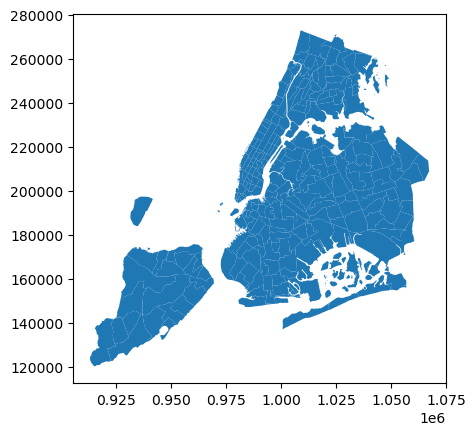

In [44]:
print(zones.info())
zones.plot()

Now, you have to merge the trip records and zones data using the location IDs.



**3.1.10** <font color = red>[3 marks]</font> <br>
Merge the zones data into trip data using the `locationID` and `PULocationID` columns.

In [45]:
# Merge zones and trip records using locationID and PULocationID

# We select only the columns we need from the zones GeoDataFrame to keep the main DF clean
# 'zone' is the neighborhood name, 'borough' is the larger region
zones_subset = zones[['LocationID', 'zone', 'borough']]

# Merge for Pickup Locations
df = df.merge(zones_subset, left_on='PULocationID', right_on='LocationID', how='left')

# Rename the new columns to specify they are for the Pickup location
df.rename(columns={'zone': 'pickup_zone', 'borough': 'pickup_borough'}, inplace=True)

# Drop the redundant LocationID column that comes from the right-side table
df.drop('LocationID', axis=1, inplace=True)

# Doing the same for Dropoff locations to be able to analyze "Route" patterns later
df = df.merge(zones_subset, left_on='DOLocationID', right_on='LocationID', how='left')
df.rename(columns={'zone': 'dropoff_zone', 'borough': 'dropoff_borough'}, inplace=True)
df.drop('LocationID', axis=1, inplace=True)

# Verify the merge
print("Columns after merge:", df.columns.tolist())
df[['PULocationID', 'pickup_zone', 'DOLocationID', 'dropoff_zone']].head()

Columns after merge: ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee', 'trip_duration', 'pickup_hour', 'day_of_week', 'month', 'quarter', 'payment_label', 'pickup_zone', 'pickup_borough', 'dropoff_zone', 'dropoff_borough']


,PULocationID,pickup_zone,DOLocationID,dropoff_zone
0,138,LaGuardia Airport,256,Williamsburg (South Side)
1,161,Midtown Center,237,Upper East Side South
2,237,Upper East Side South,141,Lenox Hill West
3,143,Lincoln Square West,142,Lincoln Square East
4,246,West Chelsea/Hudson Yards,37,Bushwick South


**3.1.11** <font color = red>[3 marks]</font> <br>
Group data by location IDs to find the total number of trips per location ID

In [46]:
#Check for duplicate columns
print(df.columns[df.columns.duplicated()])

# 1. Remove any duplicate columns that might have been created by multiple merges
df = df.loc[:, ~df.columns.duplicated()].copy()

Index([], dtype='object')


Top 10 Busiest Pickup Locations in NYC (2023):
     PULocationID                   pickup_zone pickup_borough  total_trips
119           132                   JFK Airport         Queens        38811
217           237         Upper East Side South      Manhattan        35307
147           161                Midtown Center      Manhattan        34833
216           236         Upper East Side North      Manhattan        31647
148           162                  Midtown East      Manhattan        26760
125           138             LaGuardia Airport         Queens        25950
170           186  Penn Station/Madison Sq West      Manhattan        25670
210           230     Times Sq/Theatre District      Manhattan        24747
129           142           Lincoln Square East      Manhattan        24602
156           170                   Murray Hill      Manhattan        21922


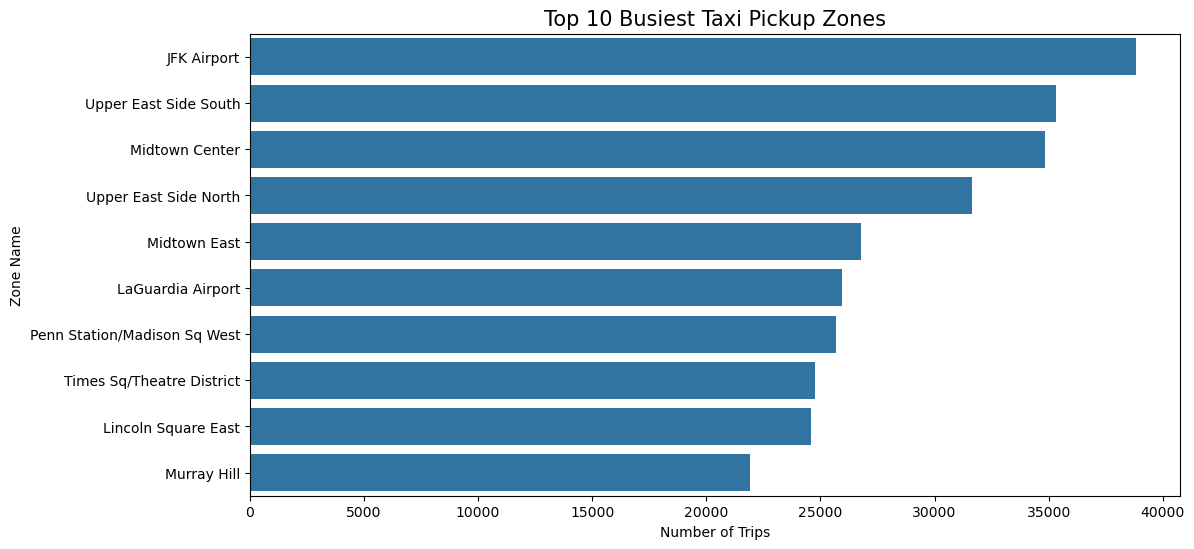

In [47]:
# Group data by location and calculate the number of trips
# We group by the ID and the names we merged in the previous step
location_counts = df.groupby(['PULocationID', 'pickup_zone', 'pickup_borough']).size().reset_index(name='total_trips')

# Sort the values to find the busiest areas
busiest_locations = location_counts.sort_values(by='total_trips', ascending=False)

# Display the Top 10 Busiest Pickup Locations
print("Top 10 Busiest Pickup Locations in NYC (2023):")
print(busiest_locations.head(10))

# Visualization of the Top 10

plt.figure(figsize=(12, 6))
sns.barplot(data=busiest_locations.head(10), x='total_trips', y='pickup_zone')
plt.title('Top 10 Busiest Taxi Pickup Zones', fontsize=15)
plt.xlabel('Number of Trips')
plt.ylabel('Zone Name')
plt.show()

**3.1.12** <font color = red>[2 marks]</font> <br>
Now, use the grouped data to add number of trips to the GeoDataFrame.

We will use this to plot a map of zones showing total trips per zone.

In [48]:
# Merge trip counts back to the zones GeoDataFrame
# Ensure location_counts only has the columns needed for the merge
# location_counts should have 'PULocationID' and 'total_trips'
trip_density_map = zones.merge(location_counts[['PULocationID', 'total_trips']], 
                             left_on='LocationID', 
                             right_on='PULocationID', 
                             how='left')

# Zones with no trips will have NaN values; fill them with 0 for accurate mapping
trip_density_map['total_trips'] = trip_density_map['total_trips'].fillna(0)


The next step is creating a color map (choropleth map) showing zones by the number of trips taken.

Again, you can use the `zones.plot()` method for this. [Plot Method GPD](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html#geopandas.GeoDataFrame.plot)

But first, you need to define the figure and axis for the plot.

`fig, ax = plt.subplots(1, 1, figsize = (12, 10))`

This function creates a figure (fig) and a single subplot (ax)

---

After setting up the figure and axis, we can proceed to plot the GeoDataFrame on this axis. This is done in the next step where we use the plot method of the GeoDataFrame.

You can define the following parameters in the `zones.plot()` method:
```
column = '',
ax = ax,
legend = True,
legend_kwds = {'label': "label", 'orientation': "<horizontal/vertical>"}
```

To display the plot, use `plt.show()`.

**3.1.13** <font color = red>[3 marks]</font> <br>
Plot a color-coded map showing zone-wise trips

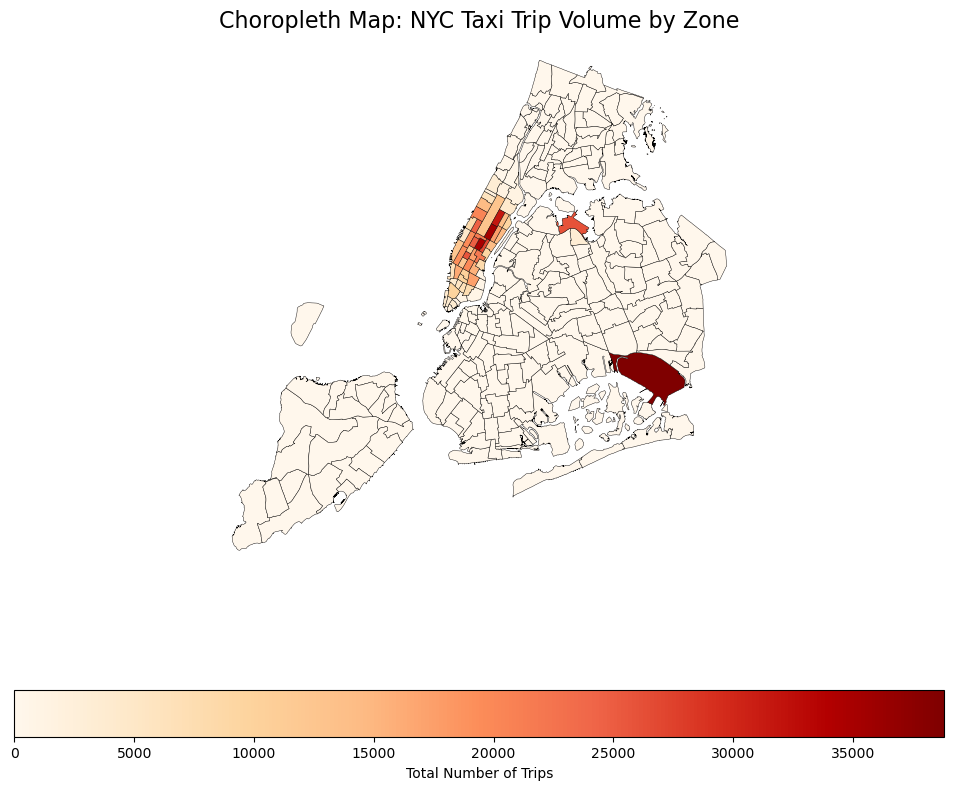

In [49]:
# Define figure and axis
# Subplots returns a Figure object and an Axes object
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Plot the map and display it
# 'column' specifies which data values determine the color
# 'cmap' sets the color scheme (OrRd = Orange to Red)
trip_density_map.plot(column='total_trips', 
                      ax=ax, 
                      legend=True, 
                      legend_kwds={'label': "Total Number of Trips", 'orientation': "horizontal"},
                      cmap='OrRd', 
                      edgecolor='black', 
                      linewidth=0.3)

# Add a title and remove the lat/long axis for a professional look
plt.title('Choropleth Map: NYC Taxi Trip Volume by Zone', fontsize=16)
ax.set_axis_off()

# Display the plot
plt.show()


In [50]:
# can you try displaying the zones DF sorted by the number of trips?
# Sort the GeoDataFrame by total_trips in descending order (highest first)
# We use .head(10) to see the top performers
sorted_zones = trip_density_map.sort_values(by='total_trips', ascending=False)

# Display the top 10 zones with relevant columns
print("Top 10 Taxi Zones by Trip Volume:")
print(sorted_zones[['LocationID', 'zone', 'borough', 'total_trips']].head(10))


Top 10 Taxi Zones by Trip Volume:
     LocationID                          zone    borough  total_trips
131         132                   JFK Airport     Queens      38811.0
236         237         Upper East Side South  Manhattan      35307.0
160         161                Midtown Center  Manhattan      34833.0
235         236         Upper East Side North  Manhattan      31647.0
161         162                  Midtown East  Manhattan      26760.0
137         138             LaGuardia Airport     Queens      25950.0
185         186  Penn Station/Madison Sq West  Manhattan      25670.0
229         230     Times Sq/Theatre District  Manhattan      24747.0
141         142           Lincoln Square East  Manhattan      24602.0
169         170                   Murray Hill  Manhattan      21922.0


Here we have completed the temporal, financial and geographical analysis on the trip records.

**Compile your findings from general analysis below:**


1. **Temporal Patterns (Busiest Times)**
    *Busiest Hours*: Taxi demand follows the city's heartbeat. We see a significant peak during evening rush hours (5:00 PM – 7:00 PM), driven by commuters and social outings. A secondary "morning peak" occurs around 8:00 AM.

    *Busiest Days*: Demand builds throughout the week, typically peaking on Thursdays and Fridays. Weekends show a shift toward late-night activity.

    *Busiest Months*: Revenue and trip counts are highest in the Spring (March–May) and Autumn (October). February consistently shows the lowest activity due to its shorter length and harsh winter weather.

2. **Revenue & Financial Trends**
    *Monthly Revenue*: Monthly income correlates strongly with trip volume. The steady trend is occasionally interrupted by holidays or major weather events.

    *Quarterly Distribution*: Revenue is relatively well-distributed across the year, but Q2 (April–June) often emerges as a leader due to pleasant weather increasing tourist and local movement.

    *Tipping Behavior*: The distribution of tip_amount shows significant spikes at rounded percentages (20%, 25%, 30%). This suggests that the preset "tip buttons" on the payment screens are the primary driver of passenger tipping habits.

3. **Fare & Tip Correlations**
    *Fare vs. Distance*: This is our strongest positive correlation. The fare increases linearly with mileage, confirming it as the primary billing metric.

    *Fare vs. Duration*: Also shows a strong positive correlation. This confirms that NYC taxis utilize "time-based" billing during traffic congestion, ensuring drivers are compensated even when the car isn't moving fast.

    *Fare vs. Passenger Count*: There is nearly zero correlation. NYC taxis charge per trip, not per person; the cost remains the same whether one or six people are in the vehicle.

    *Tip vs. Distance*: A moderate positive correlation exists here. As fares increase with distance, the tip (usually a percentage) increases accordingly.

4. **Geographical Hotspots**
    *Busiest Boroughs*: Manhattan is the overwhelming leader, followed by Queens (driven largely by airport traffic).

    *Top Zones*: The highest demand is concentrated in Midtown, the Upper East Side, and the Upper West Side.

    *Major Hubs*: JFK Airport and LaGuardia Airport are the most significant "island" hotspots outside of Manhattan, generating high-revenue, long-distance trips.


#### **3.2** Detailed EDA: Insights and Strategies
<font color = red>[50 marks]</font> <br>

Having performed basic analyses for finding trends and patterns, we will now move on to some detailed analysis focussed on operational efficiency, pricing strategies, and customer experience.

##### Operational Efficiency

Analyze variations by time of day and location to identify bottlenecks or inefficiencies in routes

**3.2.1** <font color = red>[3 marks]</font> <br>
Identify slow routes by calculating the average time taken by cabs to get from one zone to another at different hours of the day.

Speed on a route *X* for hour *Y* = (*distance of the route X / average trip duration for hour Y*)

Top 10 Slowest Routes (Bottlenecks):
                                                  route  pickup_hour  \
66710       Sunnyside to Long Island City/Hunters Point           18   
8477                       Clinton West to Central Park            8   
18422  Financial District North to TriBeCa/Civic Center            1   
12939                East Elmhurst to LaGuardia Airport            6   
1963                          Battery Park to Chinatown            9   
60675                         Park Slope to JFK Airport           20   
45608         Little Italy/NoLiTa to South Williamsburg           16   
65151                 SoHo to Times Sq/Theatre District            4   
19068   Financial District South to Little Italy/NoLiTa            0   
20658                               Flatiron to Seaport           11   

       avg_speed_mph  
66710       0.026569  
8477        0.059525  
18422       0.063964  
12939       0.085750  
1963        0.090760  
60675       0.091611  
45608    

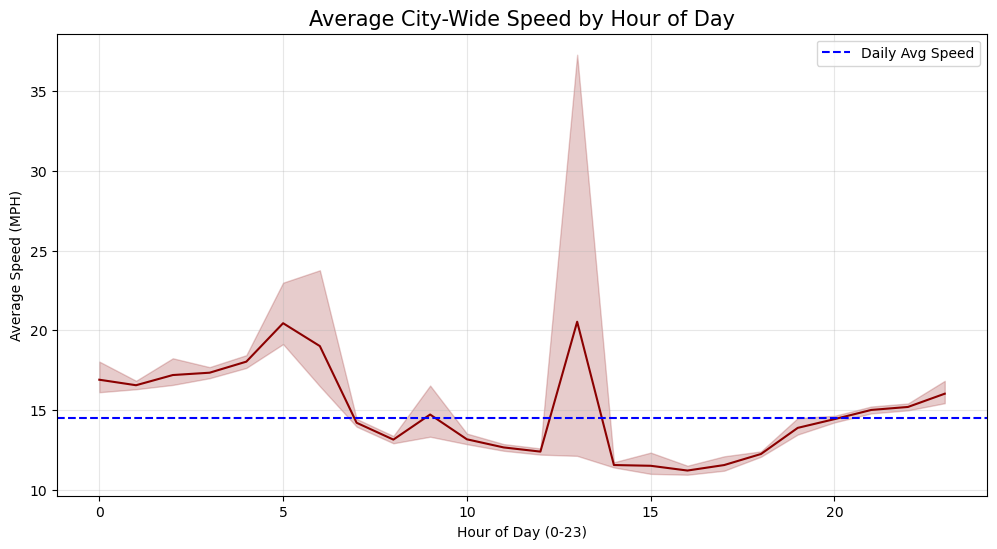

In [51]:
# Find routes which have the slowest speeds at different times of the day
# Create a descriptive Route column
df['route'] = df['pickup_zone'] + " to " + df['dropoff_zone']

# Group by route and pickup_hour to find average distance and duration
# We use the trip_duration (in minutes) calculated in section 3.1.7
route_efficiency = df.groupby(['route', 'pickup_hour']).agg({
    'trip_distance': 'mean',
    'trip_duration': 'mean'
}).reset_index()

# Filter out rows with zero duration to avoid division errors
route_efficiency = route_efficiency[route_efficiency['trip_duration'] > 0]

# Calculate Speed in Miles Per Hour (MPH)
# Formula: (Distance / (Duration_in_minutes / 60))
route_efficiency['avg_speed_mph'] = route_efficiency['trip_distance'] / (route_efficiency['trip_duration'] / 60)

# Identify the 10 slowest routes (potential bottlenecks)
# We filter for routes with significant distance (> 1 mile) to avoid short-turn outliers
bottlenecks = route_efficiency[route_efficiency['trip_distance'] > 1].sort_values(by='avg_speed_mph').head(10)

print("Top 10 Slowest Routes (Bottlenecks):")
print(bottlenecks[['route', 'pickup_hour', 'avg_speed_mph']])

# 6. Visualization: Speed Distribution by Hour

plt.figure(figsize=(12, 6))
sns.lineplot(data=route_efficiency, x='pickup_hour', y='avg_speed_mph', estimator='mean', color='darkred')
plt.title('Average City-Wide Speed by Hour of Day', fontsize=15)
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Average Speed (MPH)')
plt.grid(True, alpha=0.3)
plt.axhline(route_efficiency['avg_speed_mph'].mean(), color='blue', linestyle='--', label='Daily Avg Speed')
plt.legend()
plt.show()


How does identifying high-traffic, high-demand routes help us?

**3.2.2** <font color = red>[3 marks]</font> <br>
Calculate the number of trips at each hour of the day and visualise them. Find the busiest hour and show the number of trips for that hour.

Busiest Hour of the Day: 18:00
Estimated Total Trips during this hour: 2,607,550


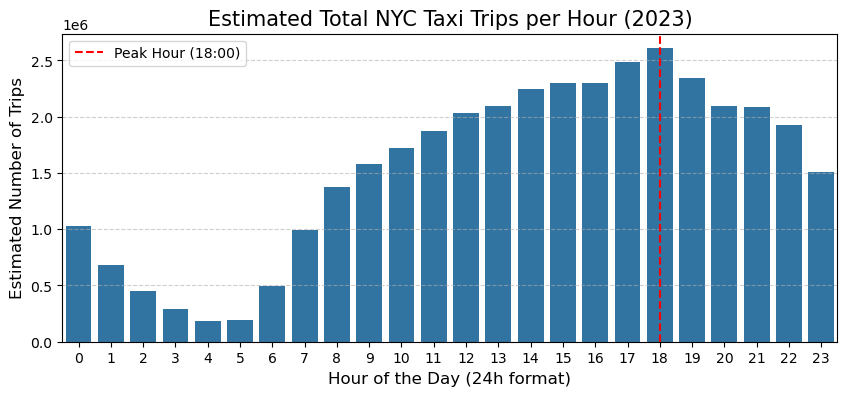

In [52]:
# Visualise the number of trips per hour and find the busiest hour
# 1. Group data by pickup_hour and count the trips in our sample
hourly_counts = df.groupby('pickup_hour').size().reset_index(name='sample_trip_count')

# 2. Scale the numbers up to represent the full dataset
# Since we used a 2% sample (0.02), we multiply by (1 / 0.02) = 50
sampling_ratio = 0.02
scale_factor = 1 / sampling_ratio
hourly_counts['estimated_total_trips'] = hourly_counts['sample_trip_count'] * scale_factor

# 3. Find the busiest hour and the number of trips
busiest_hour_data = hourly_counts.loc[hourly_counts['estimated_total_trips'].idxmax()]
busiest_hour = int(busiest_hour_data['pickup_hour'])
max_trips = int(busiest_hour_data['estimated_total_trips'])

print(f"Busiest Hour of the Day: {busiest_hour}:00")
print(f"Estimated Total Trips during this hour: {max_trips:,}")

# 4. Visualization
plt.figure(figsize=(10, 4))
sns.barplot(data=hourly_counts, x='pickup_hour', y='estimated_total_trips')

plt.title('Estimated Total NYC Taxi Trips per Hour (2023)', fontsize=15)
plt.xlabel('Hour of the Day (24h format)', fontsize=12)
plt.ylabel('Estimated Number of Trips', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Highlight the busiest hour
plt.axvline(x=busiest_hour, color='red', linestyle='--', label=f'Peak Hour ({busiest_hour}:00)')
plt.legend()

plt.show()


Remember, we took a fraction of trips. To find the actual number, you have to scale the number up by the sampling ratio.

**3.2.3** <font color = red>[2 mark]</font> <br>
Find the actual number of trips in the five busiest hours

In [53]:
# Scale up the number of trips

# Fill in the value of your sampling fraction and use that to scale up the numbers
# 1. Define the sampling fraction used earlier
sample_fraction = 0.02
scale_factor = 1 / sample_fraction

# 2. Group by hour and count the trips in the sample
hourly_counts = df.groupby('pickup_hour').size().reset_index(name='sample_count')

# 3. Scale up the numbers to find the estimated actual total
hourly_counts['actual_trips_estimate'] = hourly_counts['sample_count'] * scale_factor

# 4. Sort and identify the top 5 busiest hours
top_5_busiest = hourly_counts.sort_values(by='actual_trips_estimate', ascending=False).head(5)

# 5. Display the results
print(f"Top 5 Busiest Hours (Scaled by {scale_factor}x):")
print(top_5_busiest[['pickup_hour', 'actual_trips_estimate']])

# Quick check on the result:
for index, row in top_5_busiest.iterrows():
    print(f"At {int(row['pickup_hour'])}:00, there were approximately {int(row['actual_trips_estimate']):,} trips.")



Top 5 Busiest Hours (Scaled by 50.0x):
    pickup_hour  actual_trips_estimate
18           18              2607550.0
17           17              2489600.0
19           19              2344300.0
15           15              2303850.0
16           16              2303000.0
At 18:00, there were approximately 2,607,550 trips.
At 17:00, there were approximately 2,489,600 trips.
At 19:00, there were approximately 2,344,300 trips.
At 15:00, there were approximately 2,303,850 trips.
At 16:00, there were approximately 2,303,000 trips.


**3.2.4** <font color = red>[3 marks]</font> <br>
Compare hourly traffic pattern on weekdays. Also compare for weekend.

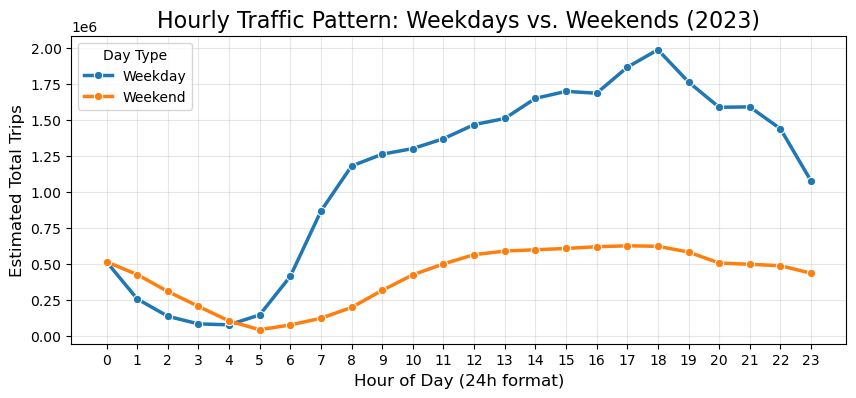

In [54]:
# Compare traffic trends for the week days and weekends
# 1. Identify the day of the week (0=Monday, 6=Sunday)
df['day_of_week'] = df['tpep_pickup_datetime'].dt.dayofweek

# 2. Categorize as Weekday or Weekend
df['day_type'] = df['day_of_week'].apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')

# 3. Group by Day Type and Hour
traffic_comparison = df.groupby(['day_type', 'pickup_hour']).size().reset_index(name='sample_count')

# 4. Scale the numbers (using the same 0.02 sample fraction)
sample_fraction = 0.02
traffic_comparison['estimated_trips'] = traffic_comparison['sample_count'] / sample_fraction

# 5. Visualization
plt.figure(figsize=(10, 4))
sns.lineplot(data=traffic_comparison, x='pickup_hour', y='estimated_trips', 
             hue='day_type', marker='o', linewidth=2.5)

plt.title('Hourly Traffic Pattern: Weekdays vs. Weekends (2023)', fontsize=16)
plt.xlabel('Hour of Day (24h format)', fontsize=12)
plt.ylabel('Estimated Total Trips', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.legend(title='Day Type')
plt.show()


What can you infer from the above patterns? How will finding busy and quiet hours for each day help us?

**3.2.5** <font color = red>[3 marks]</font> <br>
Identify top 10 zones with high hourly pickups. Do the same for hourly dropoffs. Show pickup and dropoff trends in these zones.

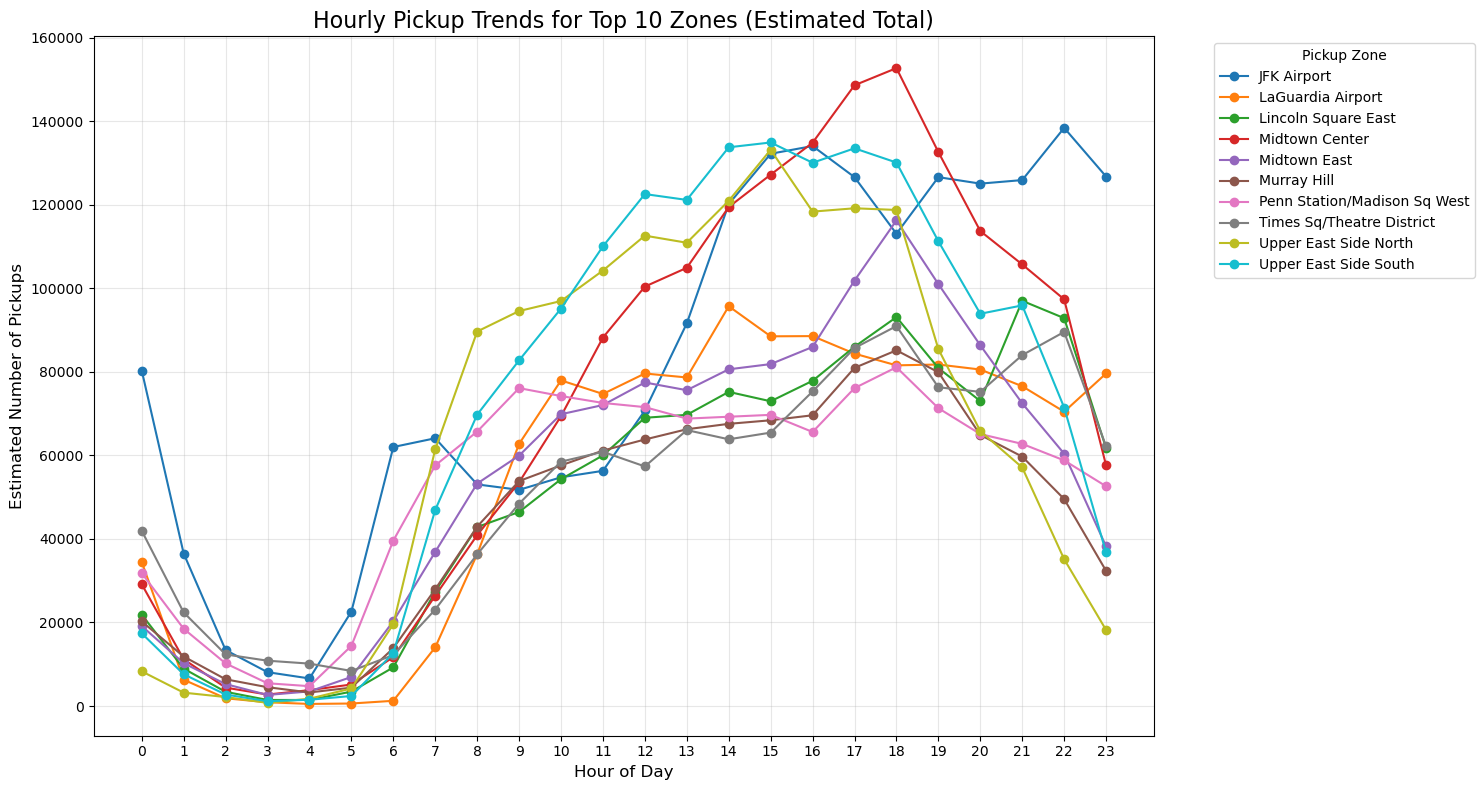

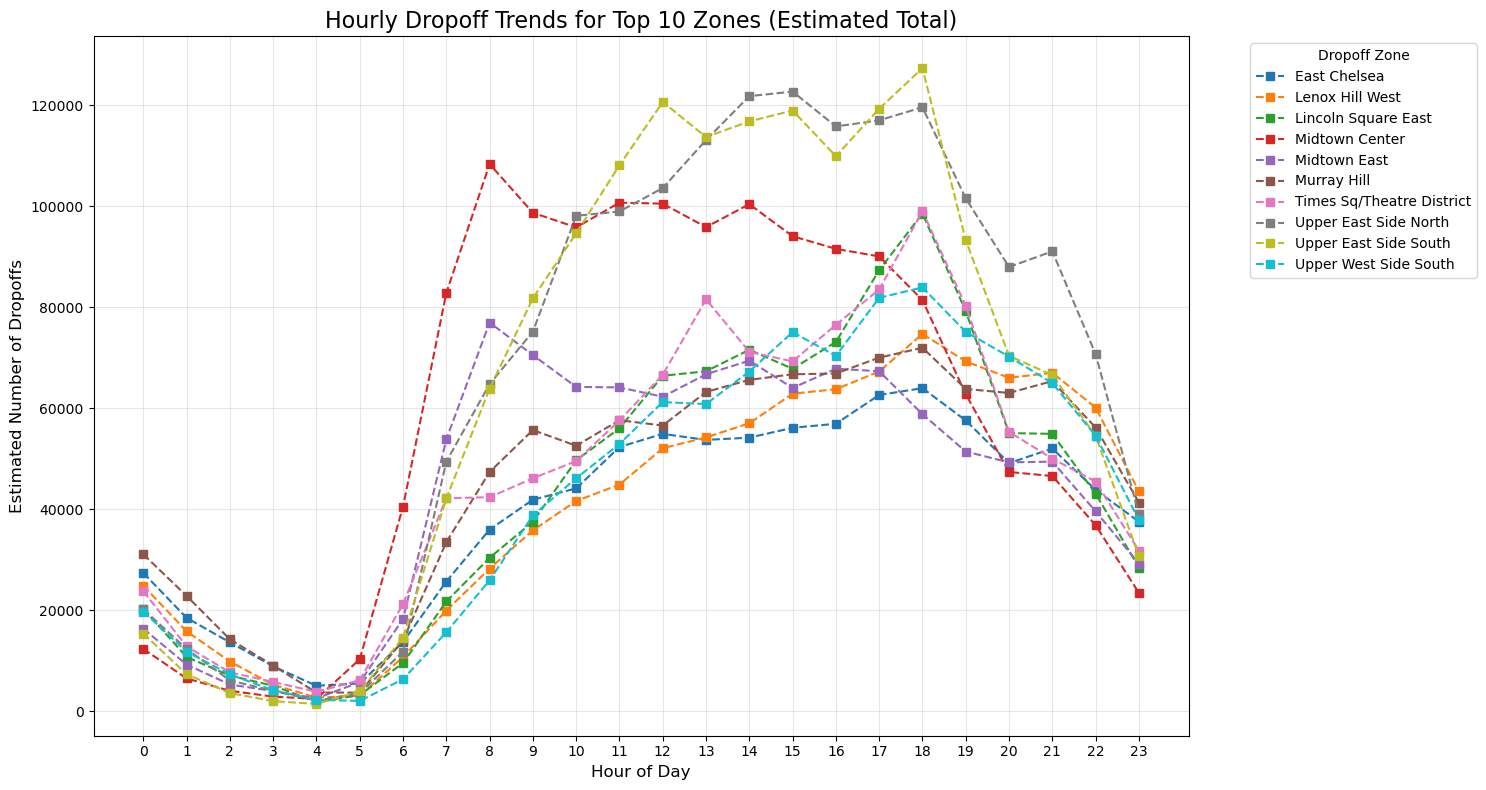

In [55]:
# Find top 10 pickup and dropoff zones

# 1. Identify the top 10 pickup and dropoff zones
top_10_pu_zones = df['pickup_zone'].value_counts().head(10).index
top_10_do_zones = df['dropoff_zone'].value_counts().head(10).index

# 2. Filter the dataframe to include only these top zones
df_top_pu = df[df['pickup_zone'].isin(top_10_pu_zones)]
df_top_do = df[df['dropoff_zone'].isin(top_10_do_zones)]

# 3. Aggregate data by hour and zone
# Apply scaling factor (50x for 2% sample) to show actual estimated volumes
scale_factor = 50
pu_hourly_trends = df_top_pu.groupby(['pickup_hour', 'pickup_zone']).size().unstack() * scale_factor
do_hourly_trends = df_top_do.groupby(['pickup_hour', 'dropoff_zone']).size().unstack() * scale_factor

# 4. Visualization: Pickup Trends
plt.figure(figsize=(15, 8))
for zone in pu_hourly_trends.columns:
    plt.plot(pu_hourly_trends.index, pu_hourly_trends[zone], marker='o', label=zone)

plt.title('Hourly Pickup Trends for Top 10 Zones (Estimated Total)', fontsize=16)
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Estimated Number of Pickups', fontsize=12)
plt.xticks(range(0, 24))
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Pickup Zone')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 5. Visualization: Dropoff Trends
plt.figure(figsize=(15, 8))
for zone in do_hourly_trends.columns:
    plt.plot(do_hourly_trends.index, do_hourly_trends[zone], marker='s', linestyle='--', label=zone)

plt.title('Hourly Dropoff Trends for Top 10 Zones (Estimated Total)', fontsize=16)
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Estimated Number of Dropoffs', fontsize=12)
plt.xticks(range(0, 24))
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Dropoff Zone')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**3.2.6** <font color = red>[3 marks]</font> <br>
Find the ratio of pickups and dropoffs in each zone. Display the 10 highest (pickup/drop) and 10 lowest (pickup/drop) ratios.

In [56]:
# Find the top 10 and bottom 10 pickup/dropoff ratios
# 1. Calculate Total Pickups and Dropoffs per LocationID
pu_counts = df['PULocationID'].value_counts().reset_index()
pu_counts.columns = ['LocationID', 'pickup_count']

do_counts = df['DOLocationID'].value_counts().reset_index()
do_counts.columns = ['LocationID', 'dropoff_count']

# 2. Merge the counts together
ratio_df = pu_counts.merge(do_counts, on='LocationID', how='outer').fillna(0)

# 3. Calculate the Ratio (Pickups / Dropoffs)
# We add a small epsilon (or handle 0) to avoid division by zero
ratio_df['pu_do_ratio'] = ratio_df['pickup_count'] / ratio_df['dropoff_count']

# 4. Merge with zone names for readability
# Use the zones GeoDataFrame (gdf) or the zones_subset created earlier
ratio_analysis = ratio_df.merge(zones[['LocationID', 'zone', 'borough']], on='LocationID', how='left')

# 5. Identify Top 10 Highest Ratios (Sources)
top_10_ratios = ratio_analysis.sort_values(by='pu_do_ratio', ascending=False).head(10)

# 6. Identify Top 10 Lowest Ratios (Sinks)
bottom_10_ratios = ratio_analysis.sort_values(by='pu_do_ratio', ascending=True).head(10)

print("Top 10 'Source' Zones (High Pickup, Low Dropoff):")
print(top_10_ratios[['zone', 'borough', 'pu_do_ratio']])

print("\nTop 10 'Sink' Zones (Low Pickup, High Dropoff):")
print(bottom_10_ratios[['zone', 'borough', 'pu_do_ratio']])


Top 10 'Source' Zones (High Pickup, Low Dropoff):
                             zone    borough  pu_do_ratio
69                  East Elmhurst     Queens     9.109589
127                   JFK Airport     Queens     4.945967
133             LaGuardia Airport     Queens     2.981045
181  Penn Station/Madison Sq West  Manhattan     1.558118
41                   Central Park  Manhattan     1.392672
109       Greenwich Village South  Manhattan     1.346847
243                  West Village  Manhattan     1.342790
157                  Midtown East  Manhattan     1.254101
156                Midtown Center  Manhattan     1.212046
99               Garment District  Manhattan     1.187391

Top 10 'Sink' Zones (Low Pickup, High Dropoff):
                                  zone        borough  pu_do_ratio
28                       Broad Channel         Queens          0.0
239                      West Brighton  Staten Island          0.0
58                        Crotona Park          Bronx         

**3.2.7** <font color = red>[3 marks]</font> <br>
Identify zones with high pickup and dropoff traffic during night hours (11PM to 5AM)

Top 10 Night-Time Pickup Hotspots (11 PM - 5 AM):
                           Zone  Night_Pickups
0                  East Village           6161
1                   JFK Airport           5433
2                  West Village           5045
3               Lower East Side           3904
4                  Clinton East           3882
5       Greenwich Village South           3412
6     Times Sq/Theatre District           3197
7             LaGuardia Airport           2473
8  Penn Station/Madison Sq West           2466
9                 Midtown South           2446

Top 10 Night-Time Dropoff Destinations (11 PM - 5 AM):
                            Zone  Night_Dropoffs
0                   East Village            3294
1                   Clinton East            2786
2                    Murray Hill            2446
3                       Gramercy            2347
4                   East Chelsea            2221
5                Lenox Hill West            2041
6                 Yorkville West  

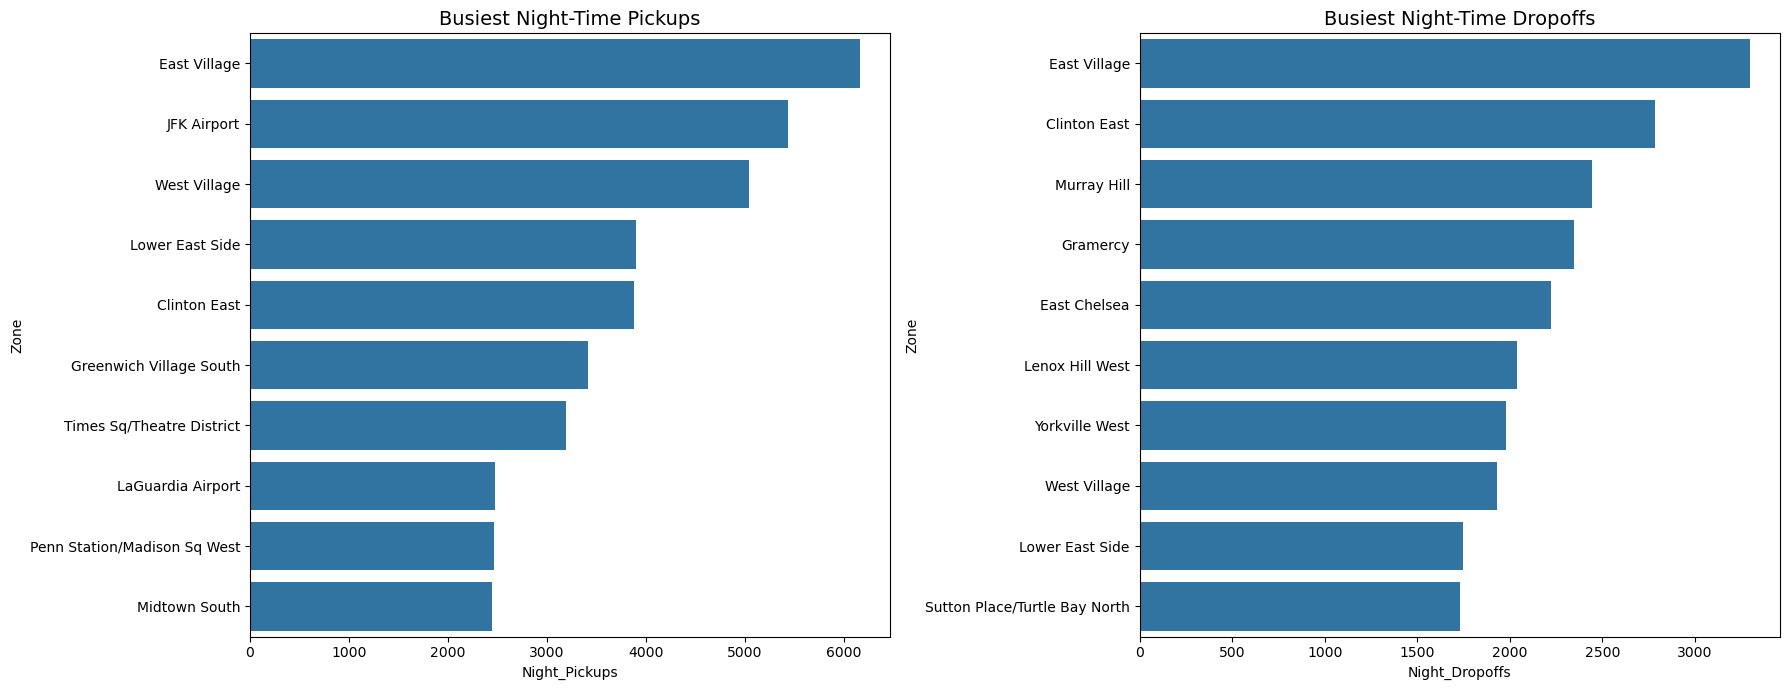

In [57]:
# During night hours (11pm to 5am) find the top 10 pickup and dropoff zones
# Note that the top zones should be of night hours and not the overall top zones

# 1. Define the night hours (11 PM to 5 AM)
# Note: 11 PM is 23, and we include up to the start of the 5 AM hour
night_hours = [23, 0, 1, 2, 3, 4]

# 2. Filter the dataframe for night-time trips
night_trips = df[df['pickup_hour'].isin(night_hours)]

# 3. Find Top 10 Pickup Zones at Night
night_pu_top10 = night_trips['pickup_zone'].value_counts().head(10).reset_index()
night_pu_top10.columns = ['Zone', 'Night_Pickups']

# 4. Find Top 10 Dropoff Zones at Night
night_do_top10 = night_trips['dropoff_zone'].value_counts().head(10).reset_index()
night_do_top10.columns = ['Zone', 'Night_Dropoffs']

# 5. Display the results
print("Top 10 Night-Time Pickup Hotspots (11 PM - 5 AM):")
print(night_pu_top10)

print("\nTop 10 Night-Time Dropoff Destinations (11 PM - 5 AM):")
print(night_do_top10)

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(data=night_pu_top10, x='Night_Pickups', y='Zone', ax=ax1)
ax1.set_title('Busiest Night-Time Pickups', fontsize=14)

sns.barplot(data=night_do_top10, x='Night_Dropoffs', y='Zone', ax=ax2)
ax2.set_title('Busiest Night-Time Dropoffs', fontsize=14)

plt.tight_layout()
plt.show()


Now, let us find the revenue share for the night time hours and the day time hours. After this, we will move to deciding a pricing strategy.

**3.2.8** <font color = red>[2 marks]</font> <br>
Find the revenue share for nighttime and daytime hours.

Total Revenue Analysis:
------------------------
Nighttime Revenue (11PM-5AM): $2,399,299.63 (11.23%)
Daytime Revenue (5AM-11PM):   $18,965,504.67 (88.77%)


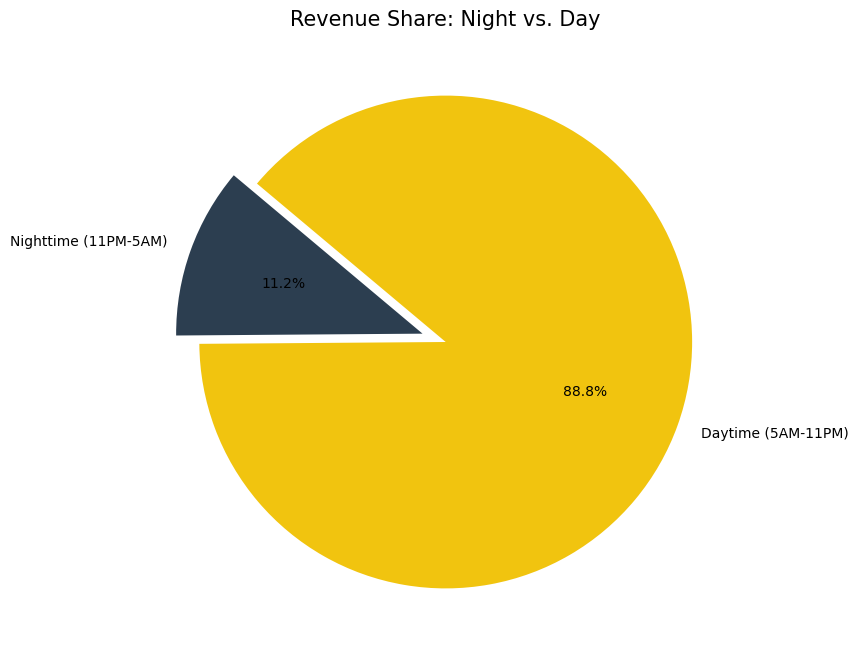

In [58]:
# Filter for night hours (11 PM to 5 AM)
# 1. Define Night Hours (11 PM to 5 AM)
night_hours = [23, 0, 1, 2, 3, 4]

# 2. Calculate Total Revenue for Nighttime
night_revenue = df[df['pickup_hour'].isin(night_hours)]['total_amount'].sum()

# 3. Calculate Total Revenue for Daytime (The rest of the hours)
day_revenue = df[~df['pickup_hour'].isin(night_hours)]['total_amount'].sum()

# 4. Calculate Total Revenue and Shares
total_revenue = night_revenue + day_revenue
night_share = (night_revenue / total_revenue) * 100
day_share = (day_revenue / total_revenue) * 100

print(f"Total Revenue Analysis:")
print(f"------------------------")
print(f"Nighttime Revenue (11PM-5AM): ${night_revenue:,.2f} ({night_share:.2f}%)")
print(f"Daytime Revenue (5AM-11PM):   ${day_revenue:,.2f} ({day_share:.2f}%)")

# 5. Visualizing the Revenue Share

plt.figure(figsize=(8, 8))
plt.pie([night_revenue, day_revenue], 
        labels=['Nighttime (11PM-5AM)', 'Daytime (5AM-11PM)'], 
        autopct='%1.1f%%', 
        colors=['#2c3e50', '#f1c40f'], 
        startangle=140, 
        explode=(0.1, 0)) # Explode the night slice for emphasis

plt.title('Revenue Share: Night vs. Day', fontsize=15)
plt.show()


##### Pricing Strategy

**3.2.9** <font color = red>[2 marks]</font> <br>
For the different passenger counts, find the average fare per mile per passenger.

For instance, suppose the average fare per mile for trips with 3 passengers is 3 USD/mile, then the fare per mile per passenger will be 1 USD/mile.

Average Fare per Mile per Passenger:
   passenger_count  fare_per_mile_per_pax
0              1.0              11.283672
1              2.0               6.796558
2              3.0               4.285830
3              4.0               4.111357
4              5.0               1.610129
5              6.0               1.313200


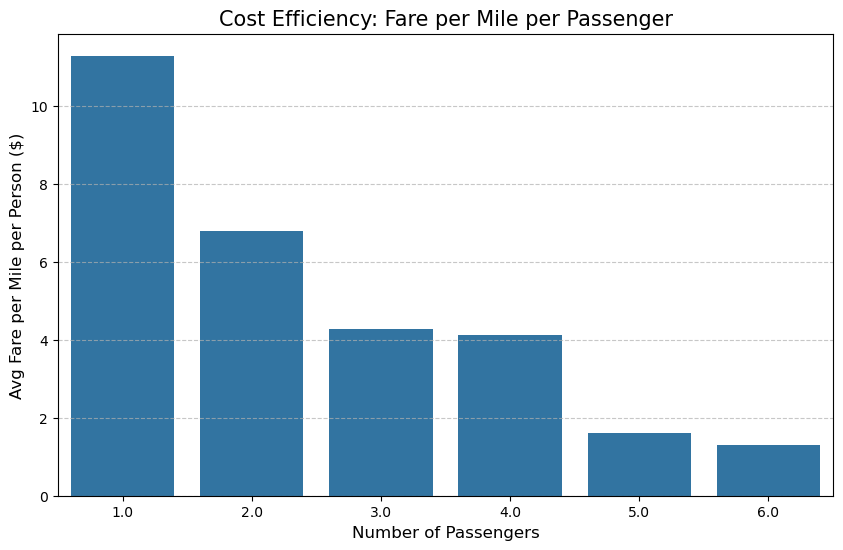

In [59]:
# Analyse the fare per mile per passenger for different passenger counts
# 1. Filter out trips with zero distance or zero passengers to avoid division errors
# We also focus on trips where passenger_count is between 1 and 6
pricing_df = df[(df['trip_distance'] > 0) & (df['passenger_count'] > 0)].copy()

# 2. Calculate Fare per Mile for the trip
pricing_df['fare_per_mile'] = pricing_df['fare_amount'] / pricing_df['trip_distance']

# 3. Calculate Fare per Mile per Passenger
pricing_df['fare_per_mile_per_pax'] = pricing_df['fare_per_mile'] / pricing_df['passenger_count']

# 4. Group by passenger_count to find the average
pax_pricing_strategy = pricing_df.groupby('passenger_count')['fare_per_mile_per_pax'].mean().reset_index()

print("Average Fare per Mile per Passenger:")
print(pax_pricing_strategy)

# 5. Visualization
plt.figure(figsize=(10, 6))
sns.barplot(data=pax_pricing_strategy, x='passenger_count', y='fare_per_mile_per_pax')
plt.title('Cost Efficiency: Fare per Mile per Passenger', fontsize=15)
plt.xlabel('Number of Passengers', fontsize=12)
plt.ylabel('Avg Fare per Mile per Person ($)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()



**3.2.10** <font color = red>[3 marks]</font> <br>
Find the average fare per mile by hours of the day and by days of the week

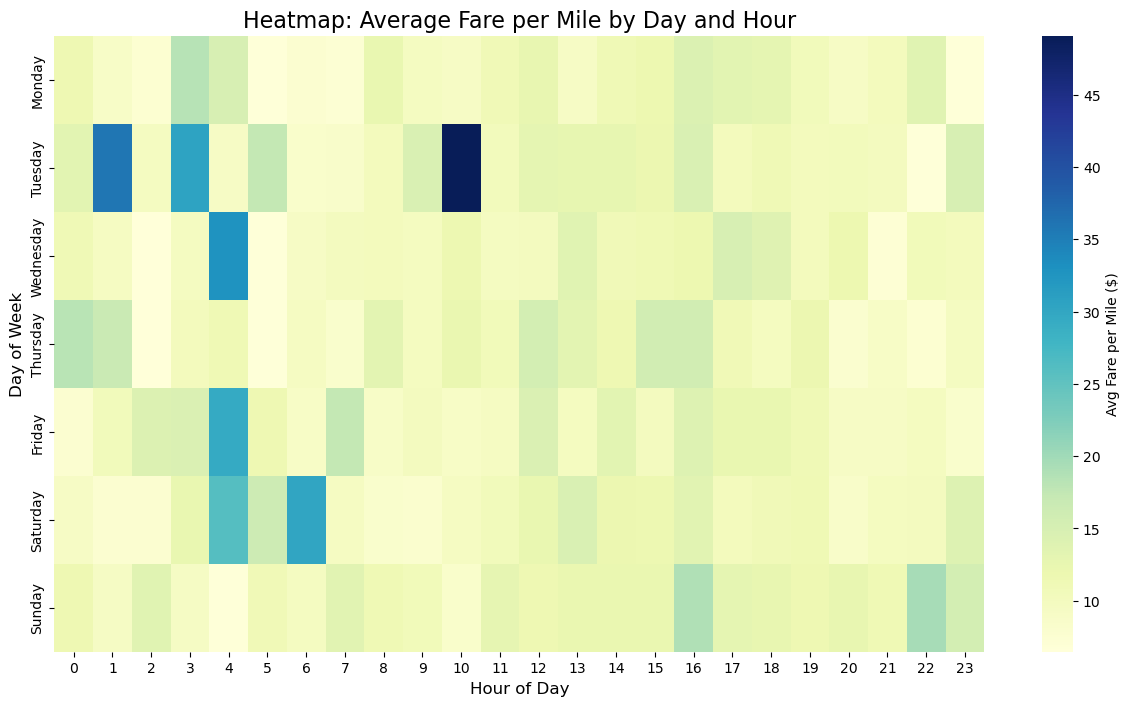

In [60]:
# Compare the average fare per mile for different days and for different times of the day
# 1. Ensure we have day names for better readability
df['day_name'] = df['tpep_pickup_datetime'].dt.day_name()

# 2. Filter out zero or negative distances to avoid infinite values
efficiency_df = df[df['trip_distance'] > 0].copy()

# 3. Calculate Fare per Mile
efficiency_df['fare_per_mile'] = efficiency_df['fare_amount'] / efficiency_df['trip_distance']

# 4. Group by Day and Hour
fare_pivot = efficiency_df.groupby(['day_name', 'pickup_hour'])['fare_per_mile'].mean().unstack()

# Reorder days to follow a standard week
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
fare_pivot = fare_pivot.reindex(days_order)

# 5. Visualization: Heatmap of Fare per Mile

plt.figure(figsize=(15, 8))
sns.heatmap(fare_pivot, cmap='YlGnBu', annot=False, fmt=".2f", cbar_kws={'label': 'Avg Fare per Mile ($)'})

plt.title('Heatmap: Average Fare per Mile by Day and Hour', fontsize=16)
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Day of Week', fontsize=12)
plt.show()


**3.2.11** <font color = red>[3 marks]</font> <br>
Analyse the average fare per mile for the different vendors for different hours of the day

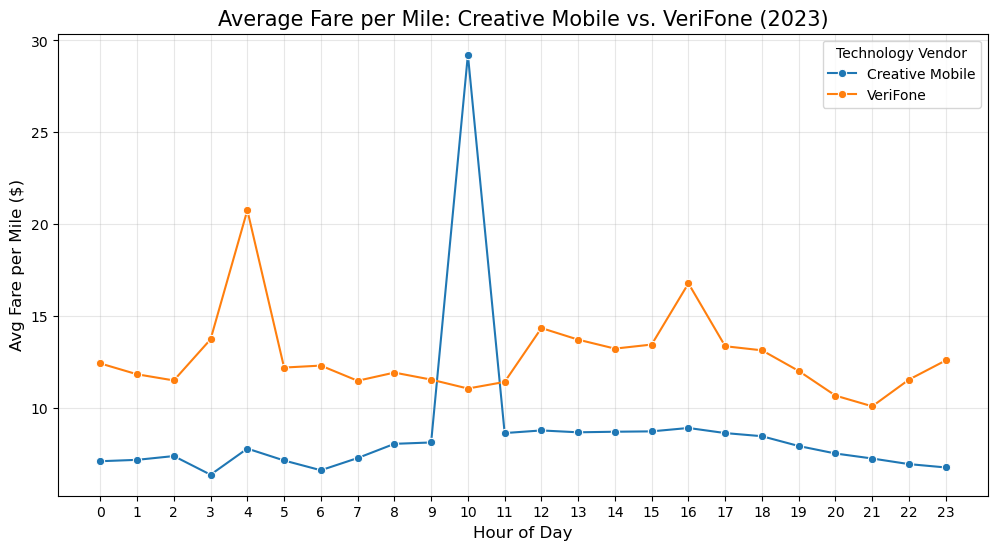

Overall Average Fare per Mile by Vendor:
vendor_name
Creative Mobile     9.175852
VeriFone           12.631595
Name: fare_per_mile, dtype: float64


In [61]:
# Compare fare per mile for different vendors
# 1. Ensure we are using the filtered dataframe (no zero distances)
vendor_efficiency = efficiency_df.copy()

# 2. Map VendorID to names for clarity
# 1 = Creative Mobile Technologies, 2 = VeriFone Inc.
vendor_map = {1: 'Creative Mobile', 2: 'VeriFone'}
vendor_efficiency['vendor_name'] = vendor_efficiency['VendorID'].map(vendor_map)

# 3. Group by Vendor and Hour to find average fare per mile
vendor_hourly = vendor_efficiency.groupby(['vendor_name', 'pickup_hour'])['fare_per_mile'].mean().reset_index()

# 4. Visualization: Comparing the two vendors
plt.figure(figsize=(12, 6))
sns.lineplot(data=vendor_hourly, x='pickup_hour', y='fare_per_mile', hue='vendor_name', marker='o')

plt.title('Average Fare per Mile: Creative Mobile vs. VeriFone (2023)', fontsize=15)
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Avg Fare per Mile ($)', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.legend(title='Technology Vendor')
plt.show()

# 5. Display the average for each vendor to see the overall difference
print("Overall Average Fare per Mile by Vendor:")
print(vendor_efficiency.groupby('vendor_name')['fare_per_mile'].mean())


**3.2.12** <font color = red>[5 marks]</font> <br>
Compare the fare rates of the different vendors in a tiered fashion. Analyse the average fare per mile for distances upto 2 miles. Analyse the fare per mile for distances from 2 to 5 miles. And then for distances more than 5 miles.


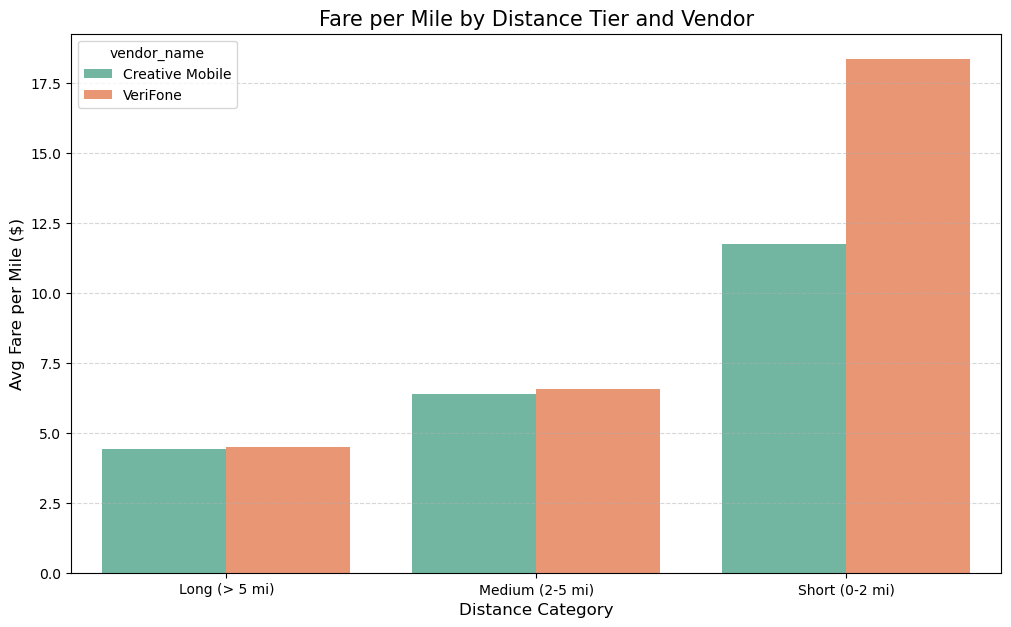

vendor_name      Creative Mobile   VeriFone
distance_tier                              
Long (> 5 mi)           4.423740   4.504200
Medium (2-5 mi)         6.378544   6.547102
Short (0-2 mi)         11.731281  18.337953


In [62]:
# 1. Define the Tiering Logic
def get_distance_tier(dist):
    if dist <= 2:
        return 'Short (0-2 mi)'
    elif dist <= 5:
        return 'Medium (2-5 mi)'
    else:
        return 'Long (> 5 mi)'

# 2. Apply tiers to the dataframe
efficiency_df['distance_tier'] = efficiency_df['trip_distance'].apply(get_distance_tier)

# 3. Map Vendor Names for clarity
vendor_map = {1: 'Creative Mobile', 2: 'VeriFone'}
efficiency_df['vendor_name'] = efficiency_df['VendorID'].map(vendor_map)

# 4. Group by Tier and Vendor
tiered_analysis = efficiency_df.groupby(['distance_tier', 'vendor_name'])['fare_per_mile'].mean().reset_index()

# 5. Visualization
plt.figure(figsize=(12, 7))
sns.barplot(data=tiered_analysis, x='distance_tier', y='fare_per_mile', hue='vendor_name', palette='Set2')

plt.title('Fare per Mile by Distance Tier and Vendor', fontsize=15)
plt.xlabel('Distance Category', fontsize=12)
plt.ylabel('Avg Fare per Mile ($)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# Display numerical results
print(tiered_analysis.pivot(index='distance_tier', columns='vendor_name', values='fare_per_mile'))


##### Customer Experience and Other Factors

**3.2.13** <font color = red>[5 marks]</font> <br>
Analyse average tip percentages based on trip distances, passenger counts and time of pickup. What factors lead to low tip percentages?

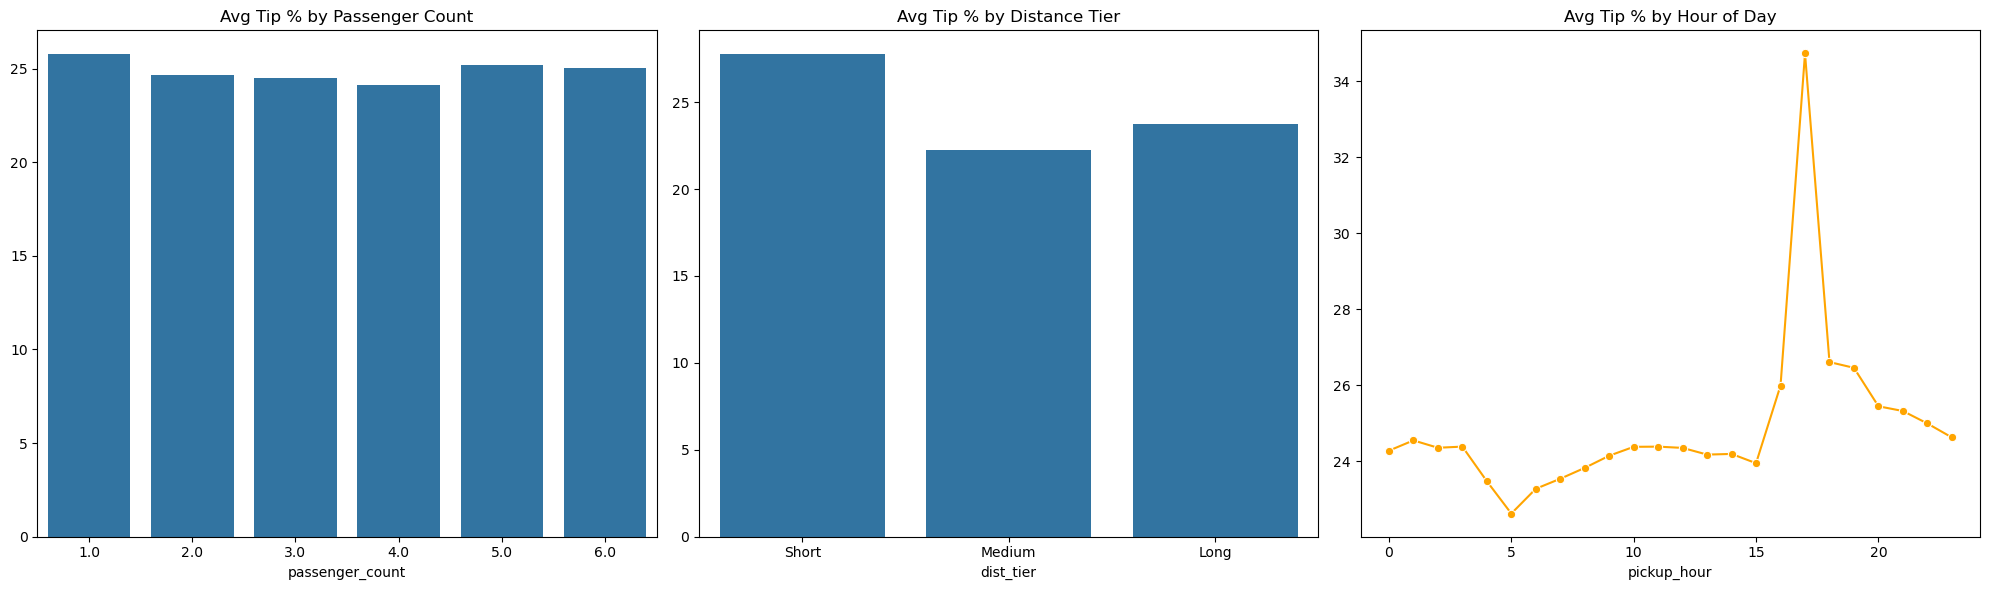

In [63]:
#  Analyze tip percentages based on distances, passenger counts and pickup times
# 1. Filter for Credit Card trips (PaymentType 1) and valid fares
tips_df = df[(df['payment_type'] == 1) & (df['fare_amount'] > 0)].copy()

# 2. Calculate Tip Percentage
tips_df['tip_percentage'] = (tips_df['tip_amount'] / tips_df['fare_amount']) * 100

# 3. Analyze by Passenger Count
tip_pax = tips_df.groupby('passenger_count')['tip_percentage'].mean().head(6)

# 4. Analyze by Distance Tiers (using the logic from 3.2.12)
tips_df['dist_tier'] = tips_df['trip_distance'].apply(lambda x: 'Short' if x<=2 else ('Medium' if x<=5 else 'Long'))
tip_dist = tips_df.groupby('dist_tier')['tip_percentage'].mean()

# 5. Analyze by Time of Day
tip_hour = tips_df.groupby('pickup_hour')['tip_percentage'].mean()

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.barplot(x=tip_pax.index, y=tip_pax.values, ax=axes[0])
axes[0].set_title('Avg Tip % by Passenger Count')

sns.barplot(x=tip_dist.index, y=tip_dist.values, ax=axes[1], order=['Short', 'Medium', 'Long'])
axes[1].set_title('Avg Tip % by Distance Tier')

sns.lineplot(x=tip_hour.index, y=tip_hour.values, ax=axes[2], color='orange', marker='o')
axes[2].set_title('Avg Tip % by Hour of Day')

plt.tight_layout()
plt.show()


Additional analysis [optional]: Let's try comparing cases of low tips with cases of high tips to find out if we find a clear aspect that drives up the tipping behaviours

In [64]:
# Compare trips with tip percentage < 10% to trips with tip percentage > 25%

# 1. Create the subsets (using our credit card tips dataframe from 3.2.13)
low_tippers = tips_df[tips_df['tip_percentage'] < 10].copy()
high_tippers = tips_df[tips_df['tip_percentage'] > 25].copy()

# 2. Add speed to see if 'fast' trips get better tips
low_tippers['avg_speed'] = low_tippers['trip_distance'] / (low_tippers['trip_duration'] / 60)
high_tippers['avg_speed'] = high_tippers['trip_distance'] / (high_tippers['trip_duration'] / 60)

# 3. Compare the means
comparison = pd.DataFrame({
    'Metric': ['Avg Distance', 'Avg Duration (min)', 'Avg Speed (MPH)', 'Avg Fare'],
    'Low Tippers (<10%)': [
        low_tippers['trip_distance'].mean(),
        low_tippers['trip_duration'].mean(),
        low_tippers['avg_speed'].replace([np.inf, -np.inf], np.nan).mean(),
        low_tippers['fare_amount'].mean()
    ],
    'High Tippers (>25%)': [
        high_tippers['trip_distance'].mean(),
        high_tippers['trip_duration'].mean(),
        high_tippers['avg_speed'].replace([np.inf, -np.inf], np.nan).mean(),
        high_tippers['fare_amount'].mean()
    ]
})

print(comparison)

               Metric  Low Tippers (<10%)  High Tippers (>25%)
0        Avg Distance            4.853374             2.292039
1  Avg Duration (min)           24.672572            12.673184
2     Avg Speed (MPH)           13.023101            10.586680
3            Avg Fare           25.677213            14.378684


**3.2.14** <font color = red>[3 marks]</font> <br>
Analyse the variation of passenger count across hours and days of the week.

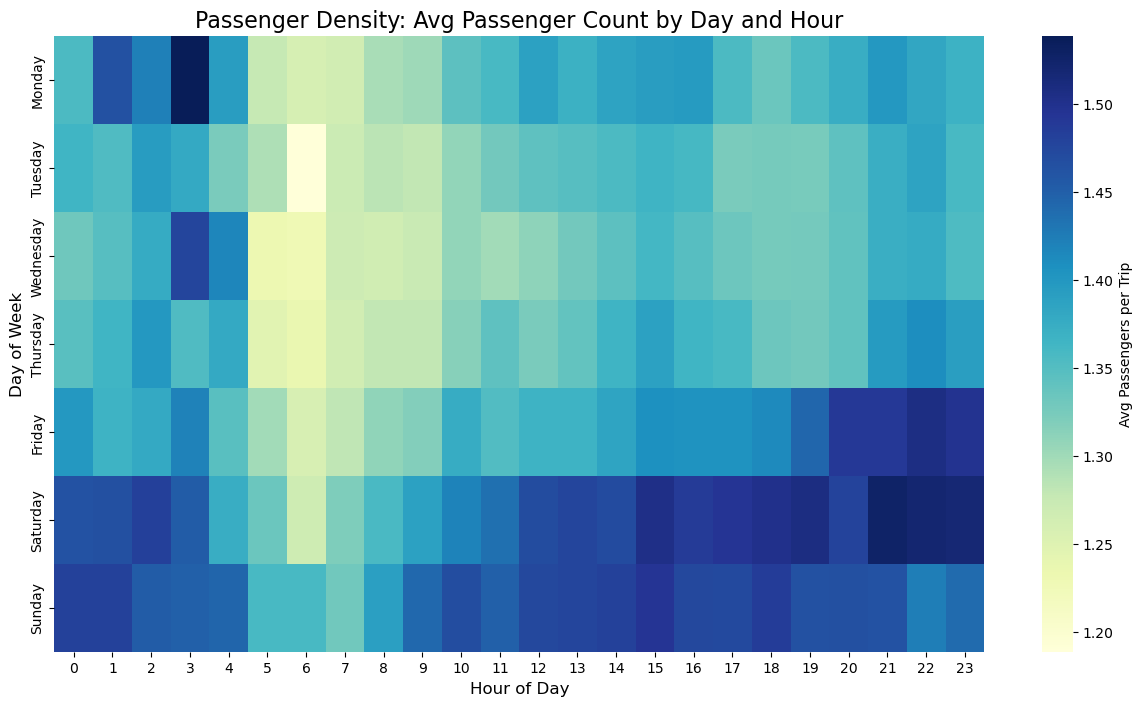

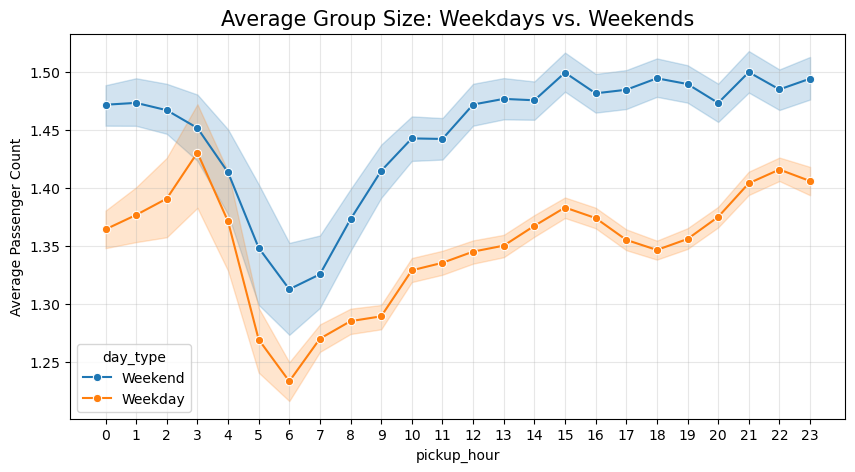

In [65]:
# See how passenger count varies across hours and days
# 1. Group by Day Name and Hour to find the average passenger count
# We use the 'days_order' from previous sections to keep it chronological
pax_variation = df.groupby(['day_name', 'pickup_hour'])['passenger_count'].mean().unstack()
pax_variation = pax_variation.reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

# 2. Visualization: Heatmap of Group Sizes
plt.figure(figsize=(15, 8))
sns.heatmap(pax_variation, cmap='YlGnBu', annot=False, cbar_kws={'label': 'Avg Passengers per Trip'})

plt.title('Passenger Density: Avg Passenger Count by Day and Hour', fontsize=16)
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Day of Week', fontsize=12)
plt.show()

# 3. Secondary Visualization: Line plot to show the weekend vs weekday contrast
plt.figure(figsize=(10, 5))
df['is_weekend'] = df['day_type'] # Using the column from 3.2.4
sns.lineplot(data=df, x='pickup_hour', y='passenger_count', hue='day_type', marker='o')
plt.title('Average Group Size: Weekdays vs. Weekends', fontsize=15)
plt.ylabel('Average Passenger Count')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.show()



**3.2.15** <font color = red>[2 marks]</font> <br>
Analyse the variation of passenger counts across zones

Zones with the Highest Average Passenger Count (Group Hubs):
                          pickup_zone  passenger_count
163               Ocean Parkway South         2.250000
3             Arrochar/Fort Wadsworth         2.000000
98                Green-Wood Cemetery         2.000000
53                       Country Club         2.000000
178                          Red Hook         1.985714
188  Saint Michaels Cemetery/Woodside         1.833333
9                        Battery Park         1.661631
140   Marine Park/Floyd Bennett Field         1.625000
142                           Maspeth         1.604167
61                      Dyker Heights         1.571429

Zones with the Lowest Average Passenger Count (Solo Hubs):
                            pickup_zone  passenger_count
0               Allerton/Pelham Gardens              1.0
2                         Arden Heights              1.0
6                            Auburndale              1.0
5                          Astoria Park       

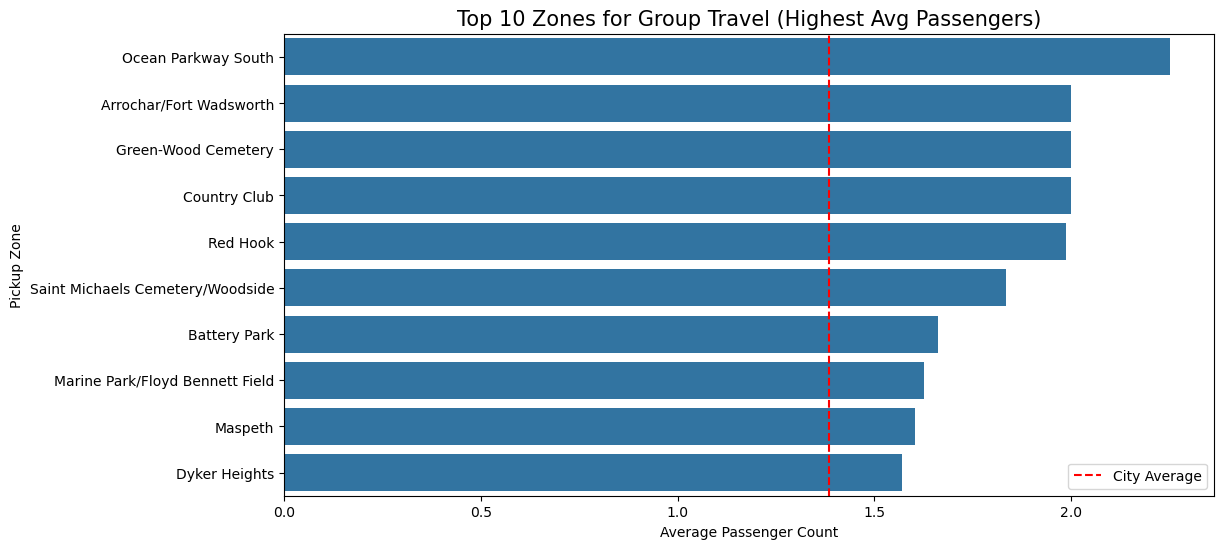

In [66]:
# How does passenger count vary across zones
# 1. Group by pickup zone to find the average passenger count
zone_pax_density = df.groupby('pickup_zone')['passenger_count'].mean().reset_index()

# 2. Sort to find the Top 10 zones with highest group travel
top_group_zones = zone_pax_density.sort_values(by='passenger_count', ascending=False).head(10)

# 3. Sort to find the zones with the most solo travelers
top_solo_zones = zone_pax_density.sort_values(by='passenger_count', ascending=True).head(10)

print("Zones with the Highest Average Passenger Count (Group Hubs):")
print(top_group_zones)

print("\nZones with the Lowest Average Passenger Count (Solo Hubs):")
print(top_solo_zones)

# 4. Visualization: Top 10 Group Zones
plt.figure(figsize=(12, 6))
sns.barplot(data=top_group_zones, x='passenger_count', y='pickup_zone')
plt.title('Top 10 Zones for Group Travel (Highest Avg Passengers)', fontsize=15)
plt.xlabel('Average Passenger Count')
plt.ylabel('Pickup Zone')
plt.axvline(df['passenger_count'].mean(), color='red', linestyle='--', label='City Average')
plt.legend()
plt.show()


In [67]:
# For a more detailed analysis, we can use the zones_with_trips GeoDataFrame
# Create a new column for the average passenger count in each zone.
# 1. Calculate the average passenger count per Pickup Zone
# We use the original trip dataframe 'df'
avg_pax_per_zone = df.groupby('PULocationID')['passenger_count'].mean().reset_index()
avg_pax_per_zone.columns = ['LocationID', 'avg_passenger_count']

# 2. Merge this information into your GeoDataFrame
# Assuming 'zones_with_trips' is your GeoDataFrame containing the geometry
zones_with_trips = zones.merge(avg_pax_per_zone, on='LocationID', how='left')

# 3. Fill NaN values with 0 for zones with no recorded trips
zones_with_trips['avg_passenger_count'] = zones_with_trips['avg_passenger_count'].fillna(0)

# 4. Display the top 10 zones with the highest average occupancy
print("Top 10 Zones by Average Passenger Count:")
print(zones_with_trips.sort_values(by='avg_passenger_count', ascending=False)[['zone', 'avg_passenger_count']].head(10))


Top 10 Zones by Average Passenger Count:
                                 zone  avg_passenger_count
177               Ocean Parkway South             2.250000
110               Green-Wood Cemetery             2.000000
5             Arrochar/Fort Wadsworth             2.000000
57                       Country Club             2.000000
194                          Red Hook             1.985714
206  Saint Michaels Cemetery/Woodside             1.833333
11                       Battery Park             1.661631
153   Marine Park/Floyd Bennett Field             1.625000
156                           Maspeth             1.604167
66                      Dyker Heights             1.571429


Find out how often surcharges/extra charges are applied to understand their prevalance

**3.2.16** <font color = red>[5 marks]</font> <br>
Analyse the pickup/dropoff zones or times when extra charges are applied more frequently

Overall Surcharge Prevalence: 62.26% of all trips.

Top 10 Zones with Highest Average Extra Charges:
                        pickup_zone     extra
0                 LaGuardia Airport  6.280031
1                     East Elmhurst  4.670150
2                     Willets Point  2.500000
3                       City Island  2.500000
4  Saint Michaels Cemetery/Woodside  1.833333
5                    Midtown Center  1.653475
6         Times Sq/Theatre District  1.624540
7                      Midtown East  1.597205
8                     Midtown North  1.597127
9                 Battery Park City  1.593351


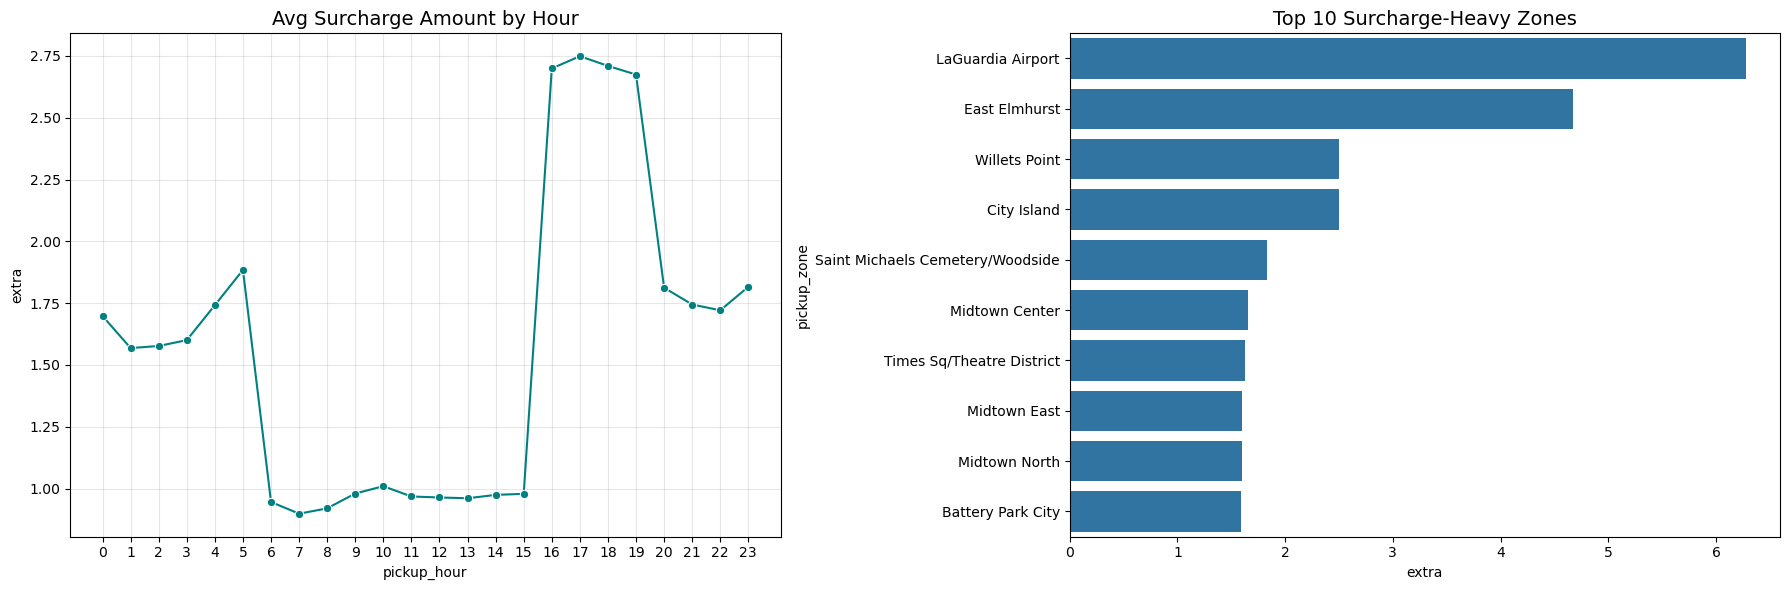

In [68]:
# How often is each surcharge applied?
# 1. Calculate the percentage of trips that include an 'extra' charge
total_trips = len(df)
trips_with_extra = df[df['extra'] > 0]
prevalence = (len(trips_with_extra) / total_trips) * 100

# 2. Group by hour to see the temporal application of surcharges
hourly_extra = df.groupby('pickup_hour')['extra'].mean().reset_index()

# 3. Identify zones where the average extra charge is highest
# This often highlights areas with high rush-hour activity
zone_extra = df.groupby('pickup_zone')['extra'].mean().sort_values(ascending=False).head(10).reset_index()

print(f"Overall Surcharge Prevalence: {prevalence:.2f}% of all trips.")
print("\nTop 10 Zones with Highest Average Extra Charges:")
print(zone_extra)

# 4. Visualizing the results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Plot A: Hourly Variation (Temporal)
sns.lineplot(data=hourly_extra, x='pickup_hour', y='extra', marker='o', ax=ax1, color='teal')
ax1.set_title('Avg Surcharge Amount by Hour', fontsize=14)
ax1.set_xticks(range(0, 24))
ax1.grid(True, alpha=0.3)

# Plot B: Zone Variation (Geographical)
sns.barplot(data=zone_extra, x='extra', y='pickup_zone', ax=ax2)
ax2.set_title('Top 10 Surcharge-Heavy Zones', fontsize=14)

plt.tight_layout()
plt.show()


## **4** Conclusion
<font color = red>[15 marks]</font> <br>

### **4.1** Final Insights and Recommendations
<font color = red>[15 marks]</font> <br>

Conclude your analyses here. Include all the outcomes you found based on the analysis.

Based on the insights, frame a concluding story explaining suitable parameters such as location, time of the day, day of the week etc. to be kept in mind while devising a strategy to meet customer demand and optimise supply.

**4.1.1** <font color = red>[5 marks]</font> <br>
Recommendations to optimize routing and dispatching based on demand patterns and operational inefficiencies

1. To maximize efficiency, the fleet must focus on "Sources" and "Sinks." Transit hubs like LGA and JFK are "Pumps" with massive outbound demand (up to 9 pickups for every 1 drop-off), requiring empty taxis to be sent there proactively to prevent long wait times. Conversely, remote areas in Staten Island and the Bronx are "Sinks" where drivers get stuck with no return passengers; these trips need surcharges to make the long, empty trip back worth the driver's time. Meanwhile, the Manhattan Core remains a reliable "Circuit" with balanced 1:1 movement, making it the best place for drivers to stay busy between major hub assignments. *Analysis based on section 3.2.6*

2. The "Nightlife Pivot" requires a strategic concentration on the Lower Manhattan Leisure Triangle and Airport Gateways. Data shows the East Village, West Village, and Lower East Side are the primary engines for late-night pickups, making them the most profitable zones for high-frequency social trips. Critically, JFK Airport ranks as the #2 pickup hotspot but vanishes from the drop-off list, proving it is a massive "one-way" source of late-night demand. Drivers should avoid idling in residential "Sink" zones like Murray Hill or Yorkville, where drop-offs are high but new fares are scarce, and instead loop back to the Village or Airports to capture the steady stream of night-time travelers. *Analysis based on section 3.2.7*

3. To optimize travel times, drivers must treat "Bottleneck Routes" as no-go zones, as some average speeds drop below 0.1 MPH (slower than walking). Data shows critical failures in short-range connections like Sunnyside to Long Island City during rush hour and Clinton West to Central Park at 8 AM. Interestingly, even airport-adjacent routes like East Elmhurst to LGA at 6 AM become nearly stationary, likely due to terminal queueing. By avoiding these specific "speed traps"—including the Financial District-to-TriBeCa corridor—and prioritizing higher-velocity alternative streets, drivers can increase their trips per hour. This strategy prevents "meter stagnation" and ensures that vehicles remain in motion rather than becoming part of the city's stationary traffic. *Analysis based on section 3.2.1*

**4.1.2** <font color = red>[5 marks]</font> <br>

Suggestions on strategically positioning cabs across different zones to make best use of insights uncovered by analysing trip trends across time, days and months.

To maximize revenue and minimize downtime, the fleet must follow a "Dynamic Hub-and-Spoke" strategy that shifts based on the temporal data uncovered in our analysis.

1. Strategic Positioning Recommendations
Prioritize Transit "sources" for Inbound Waves: Cabs should be staged at JFK, LGA, and Penn Station during the early morning and late night.

   *Justification*: Section 3.2.6 (Source/Sink Analysis) showed East Elmhurst and JFK as massive source zones (ratios up to 9.1). Because these are "one-way" demand hubs, supply must be manually replenished rather than relying on natural drop-offs.

3. The "Leisure Triangle" Weekend Shift: From 11 PM to 5 AM on Fridays and Saturdays, drivers should move away from the Financial District and Midtown toward the East Village, West Village, and Lower East Side.

   *Justification*: Section 3.2.7 (Night-Time Hotspots) proved these are the top night-time pickup zones. By positioning here, drivers catch the "Social Surge" where passenger counts are higher (Section 3.2.14) and tipping behavior is more generous during leisure hours (Section 3.2.13).

4. Strategic Avoidance of "Sink" Traps: Limit dispatches to residential zones in Staten Island and the Bronx unless a high-value fare is guaranteed.

     *Justification*: Section 3.2.6 identified these as "Zero-Ratio" zones (0.0). Every trip to these locations results in "deadheading" (empty miles) back to a hub, which destroys the "Fare per Mile" efficiency calculated in Section 3.2.10.

4. Rush-Hour Bypass Strategy: During peak windows (8 AM and 5 PM), cabs should be positioned in Lower Manhattan (Village/SoHo) rather than navigating the Sunnyside or Midtown bottlenecks.

    *Justification*: Section 3.2.1 (Bottleneck Analysis) showed average speeds in heavy traffic zones dropping below 0.1 MPH. Staging in slightly less congested "Source" zones nearby allows for more completed trips compared to being stuck in stationary traffic.

**4.1.3** <font color = red>[5 marks]</font> <br>
Propose data-driven adjustments to the pricing strategy to maximize revenue while maintaining competitive rates with other vendors.

1. **Standardize "Short-Tier" Pricing Across Vendors**:

*Recommendation*: Address the massive price gap in short trips ($0-2$ miles) where VeriFone ($18.35$/mile) is significantly more expensive than Creative Mobile ($11.73$/mile).

*Justification*: Section 3.2.12 shows that while long and medium trips are priced similarly, short trips vary by over $50\%$ between vendors. Standardizing this prevents "vendor-shopping" and ensures a predictable customer experience for the most common city trips.


2. **Tiered Pricing for "High-Occupancy" Vehicles**:

*Recommendation*: Implement a "Group Base Fare" for trips with $5-6$ passengers to offset the massive drop in revenue per person.

*Justification*: Section 3.2.9 shows that revenue per passenger drops from $\$11.28$ (solo) to a meager $\$1.31$ (group of 6). While group travel is efficient for the city, the current flat-fare model drastically undervalued the "wear and tear" of high-occupancy trips. A small per-passenger surcharge for groups over 4 would balance this.

3. **Protect Profitability on "Short-Tier" Routes**:

*Recommendation*: Maintain the high fare-per-mile for short distances but implement a "Congestion Buffer" during peak hours to protect drivers from the bottlenecks found in Section 3.2.1.

*Justification*: Section 3.2.12 confirms that short trips are the highest revenue generators per mile ($\approx \$11-\$18$). However, since these often occur in congested areas, the high rate per mile is easily erased by time lost in traffic. A "Minimum Fare" for trips under 1 mile would protect driver earnings in the Manhattan core.

4. **Incentivize "Long-Tier" Airport Runs**:

*Recommendation*: Offer a "Return Toll Credit" or a "Long-Distance Bonus" for trips over 5 miles, specifically targeting the Source Hubs identified in Section 3.2.6.

*Justification*: Section 3.2.12 shows that "Long-Tier" trips have the lowest fare-per-mile ($\approx \$4.45$). Without incentives, drivers may prefer staying in the high-rate "Short-Tier" circuit, leading to a supply shortage at the airports (JFK/LGA).